In [49]:
from collections import Counter
import itertools

from scipy.stats import pearsonr

import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tqdm
from statsmodels.stats.contingency_tables import mcnemar
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.rates import test_poisson_2indep


from natsort import natsorted
import dendropy
 
from netam.sequences import (AA_STR_SORTED)
from netam import framework
from dnsmex import dxsm_data, dnsm_zoo
from dnsmex.dnsm_oe import write_sites_oe
from dnsmex.local import localify


from mutation_rates_on_different_backgrounds import compare_mutation_rates_on_different_backgrounds

figures_dir = localify("FIGURES_DIR")

## Prep data - Rodriguez dataset

In [2]:
%%bash
## get counts of V and J genes
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 11 | cut -d '-' -f 1 | sort | uniq -c | sort -nr
echo "---"
zcat /fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v1/rodriguez-airr-seq-race-prod-InclMutInv_pcp_2024-11-12_MASKED_NI_noN_no-naive_addJ.csv.gz | tail -n +2 | cut -d ',' -f 20 | cut -d '*' -f 1 | sort | uniq -c | sort -nr

   9985 IGHV3
   5246 IGHV4
   4328 IGHV1
    944 IGHV5
    771 IGHV2
    351 IGHV6
    129 IGHV7
---
  11562 IGHJ4
   3563 IGHJ6
   2863 IGHJ5
   2825 IGHJ3
    562 IGHJ2
    379 IGHJ1


In [3]:
dataset_name = "v1rodriguez"
model_name = "dnsm_1m-v1jaffe+v1tang-joint"

crepe_prefix = localify(f"DNSM_TRAINED_MODELS_DIR/{model_name}")
test_output_prefix = localify(f"DNSM_TEST_OUTPUT_DIR/{model_name}-ON-{dataset_name}")

try:
    site_sub_probs_df = pd.read_csv(f"{test_output_prefix}-site_sub_probs_df.csv")
    pcp_df = pd.read_csv(f"{test_output_prefix}-pcp_df.csv")


except FileNotFoundError:
    if not os.path.exists(f"{test_output_prefix}.branch_lengths_csv"):
        dnsm_zoo.write_branch_lengths("/fh/fast/matsen_e/shared/bcr-mut-sel/dnsm/dnsm-experiments-1/dnsm-train/trained_models/dnsm_1m-v1jaffe+v1tang-joint", dataset_name, f"{test_output_prefix}.branch_lengths_csv")


    complete_plotter, plotter_dict = write_sites_oe(
        crepe_prefix=crepe_prefix,
        dataset_name=dataset_name,
        branch_length_path=f"{test_output_prefix}.branch_lengths_csv",
        csv_output_path=f"{test_output_prefix}-sites-oe.csv",
        fig_out_path=f"{figures_dir}/sites-oe-V1,3,4.svg",
        min_log_prob=-4,
        #v_families=["IGHV1", "IGHV2", "IGHV3", "IGHV4", "IGHV5", "IGHV6", "IGHV7"],
        replace_title=True,
    )
    complete_plotter = complete_plotter["heavy"]


    pcp_df = complete_plotter.pcp_df.copy()
    site_sub_probs_df = complete_plotter.site_sub_probs_df.copy()
    for column_name in ['selection_factor', 'neutral_prob', 'prob']:
        site_sub_probs_df[column_name] = site_sub_probs_df[column_name].apply(lambda x: x.item() if hasattr(x, 'item') else x)


    pcp_df.to_csv(f"{test_output_prefix}-pcp_df.csv", index=False)
    site_sub_probs_df.to_csv(f"{test_output_prefix}-site_sub_probs_df.csv", index=False)



    def site_sub_probs_df_without_low_freq(in_plotter, quantile_cutoff=0.05):
        site_sub_probs_df = in_plotter.site_sub_probs_df.copy()
        site_counts = site_sub_probs_df["site"].value_counts()
        cutoff = site_counts.quantile(quantile_cutoff)
        sites_above_cutoff = set(site_counts[site_counts > cutoff].index)
        site_sub_probs_df = site_sub_probs_df[site_sub_probs_df["site"].isin(sites_above_cutoff)]
        return site_sub_probs_df

    def sort_df_by_site(df):
        sorted_index = natsorted(df.index, key=lambda x: df.loc[x, 'site'])
        return df.iloc[sorted_index]

    def build_persite_df(site_sub_probs_df):
        persite_df = site_sub_probs_df.groupby(['site', 'is_cdr']).agg(
            mean_prob=('prob', 'mean'),
            mean_neutral_prob=('neutral_prob', 'mean'),
            mean_selection_factor=('selection_factor', 'mean'),
            mut_freq=('mutation', 'mean')
        ).reset_index()

        persite_df = sort_df_by_site(persite_df)

        return persite_df



In [4]:
# add family annotations to aa and site substitution dfs
pcp_df['j_family'] = pcp_df['j_gene'].str.split('*').str[0]
pcp_df_for_merge = pcp_df.copy()
pcp_df_for_merge = pcp_df_for_merge[['v_gene', 'j_gene', 'v_family', 'j_family', 'sample_id', 'family', 'distance', 'branch_length', 'parent_name', 'child_name']]
pcp_df_for_merge['pcp_index'] = pcp_df_for_merge.index

site_sub_probs_df = pd.merge(site_sub_probs_df, pcp_df_for_merge, on='pcp_index', how='inner')

site_sub_probs_df['log_selection_factor'] = np.log(site_sub_probs_df['selection_factor'])

site_sub_probs_df['mutations_per_branch'] = site_sub_probs_df.groupby('pcp_index')['mutation'].transform('sum')


<Axes: xlabel='site', ylabel='Count'>

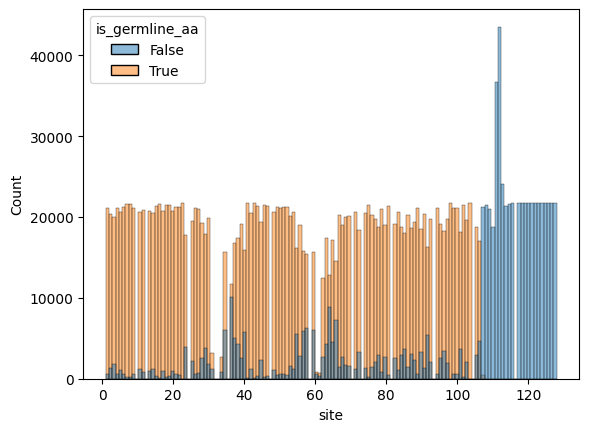

In [5]:
## add germline information
germline_codons_df = pd.read_csv(localify(f"DATA_DIR/germline_codons.csv"))
codon_similarity = pd.read_csv(localify(f"DATA_DIR/germline_codon_similarity.csv"))
aa_similarity = pd.read_csv(localify(f"DATA_DIR/germline_aa_similarity.csv"))
aa_similarity.set_index('v_gene', inplace=True)
codon_similarity.set_index('v_gene', inplace=True)





germline_codons_df['site'] = germline_codons_df['site'].astype(float)

site_sub_probs_df_germline = pd.merge(site_sub_probs_df, germline_codons_df.rename(columns={'codon':'germline_codon', 'amino_acid':'germline_amino_acid'}).drop(columns=['v_family']), on=['v_gene', 'site'], how='left')

site_sub_probs_df_germline['is_germline_aa'] = site_sub_probs_df_germline.parent_aa == site_sub_probs_df_germline.germline_amino_acid
site_sub_probs_df_germline['is_germline_codon'] = site_sub_probs_df_germline.parent_codon == site_sub_probs_df_germline.germline_codon
sns.histplot(site_sub_probs_df_germline, x='site', hue='is_germline_aa')

In [6]:
site_sub_probs_df_germline

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,distance,branch_length,parent_name,child_name,log_selection_factor,mutations_per_branch,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon
0,0.102066,0.132334,0.013507,False,0,1.0,False,CAG,Q,CAG,...,0.096444,0.082506,Node1,1TGCGTTGTAGCT,-2.022430,13,CAG,Q,True,True
1,0.030019,0.132334,0.003972,False,1,1.0,False,CAG,Q,CAG,...,0.031971,0.018034,Node1,Node2,-2.022430,1,CAG,Q,True,True
2,0.011072,0.229902,0.002546,False,2,1.0,False,CAG,Q,CAG,...,0.079722,0.002823,Node1,Node2,-1.470103,0,CAG,Q,True,True
3,0.054606,0.262477,0.014333,False,3,1.0,False,CAG,Q,CAG,...,0.094379,0.029887,Node1,1GGGCACTATGCA,-1.337593,4,CAG,Q,True,True
4,0.010781,0.262477,0.002830,False,4,1.0,False,CAG,Q,CAG,...,0.069703,0.005211,Node1,1GCAGGGCACTCT,-1.337593,1,CAG,Q,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2646366,0.001440,1.122413,0.001617,False,21747,128.0,False,TCA,S,TCA,...,0.039758,0.002731,Node1,1TCGGCAATGTAT,0.115481,0,NaN,NaN,False,False
2646367,0.001785,1.077277,0.001923,False,21748,128.0,False,TCA,S,TCA,...,0.109737,0.002848,Node1,Node2,0.074437,0,NaN,NaN,False,False
2646368,0.001744,1.077277,0.001879,False,21749,128.0,False,TCA,S,TCA,...,0.112585,0.002848,Node2,1TTTGTTCCTATG,0.074437,1,NaN,NaN,False,False
2646369,0.001797,1.249783,0.002246,False,21750,128.0,False,TCA,S,TCA,...,0.119753,0.002803,Node1,1AAAGGGCCAGTT,0.222970,1,NaN,NaN,False,False


In [7]:
def is_parent_child_one_mutation_away(parent_codon, child_codon):
    """
    Check if two codons are one mutation away from each other.
    """
    if parent_codon == child_codon:
        return False
    # Check if they differ by exactly one nucleotide mutation
    mutations = sum(1 for p, c in zip(parent_codon, child_codon) if p != c)
    return mutations == 1

site_sub_probs_df_germline['is_one_mutation_away'] = site_sub_probs_df_germline.apply(
    lambda row: is_parent_child_one_mutation_away(row['parent_codon'], row['child_codon']),
    axis=1
)

In [8]:
site_sub_probs_df_germline.groupby(['mutation', 'is_one_mutation_away']).size().reset_index()


,mutation,is_one_mutation_away,0
0,False,False,2450908
1,False,True,72290
2,True,False,22033
3,True,True,101140


## Parse trees for lineage relationships - not used for now but leaving code for future reference

In [9]:
trees_df = pd.read_csv('/fh/fast/matsen_e/shared/bcr-mut-sel/pcps/v3/trees/rodriguez-airr-seq-race-prod-NoWinCheck_igh_trees_2024-11-12.csv.gz', compression='gzip')

In [ ]:
def create_ancestral_pairs(newick_string):
    """
    Adapted from pcp pipeline.
    Changes:
    - creates parent-child pairs for all ancestral relationships, not just the immediate parent-child relationships
    - handles naive sequence as special outgroup (like original code)
    
    Args:
        newick_string (str): Newick format tree string
        
    Returns:
        dict: Dictionary containing lists of data for each column
    """
    
    def node_name(node):
        """Helper function to get node name"""
        if node.taxon and node.taxon.label:
            return node.taxon.label
        elif hasattr(node, 'label') and node.label:
            return node.label
        else:
            return f"internal_{id(node)}"
    
    # Load the tree from string
    tree = dendropy.Tree.get(data=newick_string, schema="newick", preserve_underscores=True)
    
    # Initialize column data dictionary
    coldata = {
        'parent_name': [],
        'child_name': [],
        'branch_length': [],
        'depth': [],
        'distance': [],
        'parent_is_naive': [],
        'child_is_leaf': []
    }
    
    # Traverse through the tree and accumulate depth and distance info for each node
    node_data = {}
    for nd in tree.preorder_node_iter():
        if nd.parent_node is None:
            node_data[node_name(nd)] = [0, 0]
        else:
            par_name = node_name(nd.parent_node)
            depth = node_data[par_name][0] + 1
            distance = node_data[par_name][1] + nd.edge_length
            node_data[node_name(nd)] = [depth, distance]
    
    # Naive sequence is used as outgroup (a leaf node), need to adjust info
    # so it corresponds to naive sequence as being the root of the lineage
    if 'naive' in node_data:
        naive_dist_offset = node_data['naive'][1]
        node_data['naive'] = [0, 0]
        for nd_name in node_data.keys():
            if nd_name != 'naive':
                node_data[nd_name][0] += 1
                node_data[nd_name][1] += naive_dist_offset
    
    # Function to get all ancestors of a node
    def get_all_ancestors(node):
        """Get all ancestor nodes from a given node up to the root"""
        ancestors = []
        current = node.parent_node
        while current is not None:
            ancestors.append(current)
            current = current.parent_node
        return ancestors
    
    # Create entries for all ancestral relationships
    for nd in tree.preorder_node_iter():
        if nd.parent_node is not None:  # Skip root node
            
            # Skip naive node - we'll handle all naive relationships separately
            if node_name(nd) == 'naive':
                continue
                
            # Normal processing for non-naive nodes
            child_name = node_name(nd)
            child_is_leaf = nd.is_leaf()
            
            # Get all ancestors of this node
            ancestors = get_all_ancestors(nd)
            
            # Create a relationship entry for each ancestor
            for ancestor in ancestors:
                ancestor_name = node_name(ancestor)
                
                # Skip if ancestor is naive (we handle naive separately below)
                if ancestor_name == 'naive':
                    continue
                
                par_name = ancestor_name
                nd_name = child_name
                parent_is_naive = False
                actual_child_is_leaf = child_is_leaf
                
                # Branch length is the total distance from ancestor to child
                branch_length = node_data[child_name][1] - node_data[ancestor_name][1]
                
                # Add the relationship to coldata
                coldata['parent_name'].append(par_name)
                coldata['child_name'].append(nd_name)
                coldata['branch_length'].append(branch_length)
                coldata['depth'].append(node_data[nd_name][0])
                coldata['distance'].append(node_data[nd_name][1])
                coldata['parent_is_naive'].append(parent_is_naive)
                coldata['child_is_leaf'].append(actual_child_is_leaf)
    
    # Add naive as ancestor to ALL non-naive nodes (since naive is now the root)
    if 'naive' in node_data:
        for nd in tree.preorder_node_iter():
            child_name = node_name(nd)
            
            # Skip naive itself
            if child_name == 'naive':
                continue
            
            # Add naive -> child relationship
            par_name = 'naive'
            nd_name = child_name
            parent_is_naive = True
            child_is_leaf = nd.is_leaf()
            
            # Branch length is the total distance from naive (root) to child
            branch_length = node_data[child_name][1] - node_data['naive'][1]  # This will be node_data[child_name][1] since naive distance is 0
            
            # Add the relationship to coldata
            coldata['parent_name'].append(par_name)
            coldata['child_name'].append(nd_name)
            coldata['branch_length'].append(branch_length)
            coldata['depth'].append(node_data[nd_name][0])
            coldata['distance'].append(node_data[nd_name][1])
            coldata['parent_is_naive'].append(parent_is_naive)
            coldata['child_is_leaf'].append(child_is_leaf)
    
    return coldata


def process_trees_to_ancestral_pairs(trees_df):
    """
    Process a dataframe of trees to create all ancestral pairs.
    
    Args:
        trees_df (pd.DataFrame): DataFrame with columns 'sample_id', 'family', 'newick'
        
    Returns:
        pd.DataFrame: DataFrame with all ancestral pairs and sample_id/family info
    """
    
    # Initialize lists to collect all data
    all_data = {
        'sample_id': [],
        'family': [],
        'parent_name': [],
        'child_name': [],
        'branch_length': [],
        'depth': [],
        'distance': [],
        'parent_is_naive': [],
        'child_is_leaf': []
    }
    
    # Process each row in trees_df with progress bar
    for idx, row in tqdm.tqdm(trees_df.iterrows(), total=len(trees_df), desc="Processing trees"):
        sample_id = row['sample_id']
        family = row['family']
        newick_string = row['newick']
        
        try:
            # Get ancestral pairs for this tree
            tree_data = create_ancestral_pairs(newick_string)
            
            # Add sample_id and family to each pair
            num_pairs = len(tree_data['parent_name'])
            
            # Extend all_data with this tree's data
            all_data['sample_id'].extend([sample_id] * num_pairs)
            all_data['family'].extend([family] * num_pairs)
            all_data['parent_name'].extend(tree_data['parent_name'])
            all_data['child_name'].extend(tree_data['child_name'])
            all_data['branch_length'].extend(tree_data['branch_length'])
            all_data['depth'].extend(tree_data['depth'])
            all_data['distance'].extend(tree_data['distance'])
            all_data['parent_is_naive'].extend(tree_data['parent_is_naive'])
            all_data['child_is_leaf'].extend(tree_data['child_is_leaf'])
            
        except Exception as e:
            print(f"Error processing tree for sample_id={sample_id}, family={family}: {e}")
            continue
    
    # Create final dataframe
    result_df = pd.DataFrame(all_data)
    
    return result_df

# Usage:
ancestral_pairs_df = process_trees_to_ancestral_pairs(trees_df)
print(f"Created {len(ancestral_pairs_df)} ancestral pairs from {len(trees_df)} trees")
print(ancestral_pairs_df.head())


Processing trees: 100%|██████████| 31132/31132 [00:09<00:00, 3159.61it/s]


Created 2185462 ancestral pairs from 31132 trees
         sample_id  family parent_name     child_name  branch_length  depth  \
0  sample-igg-SC-1       5       Node1  2TCAAGGGTTCTA       0.050750      2   
1  sample-igg-SC-1       5       Node1          Node2       0.037790      2   
2  sample-igg-SC-1       5       Node2  2CTTCTAATGATC       0.013707      3   
3  sample-igg-SC-1       5       Node1  2CTTCTAATGATC       0.051497      3   
4  sample-igg-SC-1       5       Node2          Node3       0.048303      3   

   distance  parent_is_naive  child_is_leaf  
0  0.058116            False           True  
1  0.045156            False          False  
2  0.058863            False           True  
3  0.058863            False           True  
4  0.093459            False          False  


In [ ]:
ancestral_pairs_df[(ancestral_pairs_df.family == 5) & (ancestral_pairs_df.sample_id == 'sample-igg-SC-1')]

,sample_id,family,parent_name,child_name,branch_length,depth,distance,parent_is_naive,child_is_leaf
0,sample-igg-SC-1,5,Node1,2TCAAGGGTTCTA,0.050750,2,0.058116,False,True
1,sample-igg-SC-1,5,Node1,Node2,0.037790,2,0.045156,False,False
2,sample-igg-SC-1,5,Node2,2CTTCTAATGATC,0.013707,3,0.058863,False,True
3,sample-igg-SC-1,5,Node1,2CTTCTAATGATC,0.051497,3,0.058863,False,True
4,sample-igg-SC-1,5,Node2,Node3,0.048303,3,0.093459,False,False
5,sample-igg-SC-1,5,Node1,Node3,0.086093,3,0.093459,False,False
6,sample-igg-SC-1,5,Node3,1GCAGGCCTATGC,0.000001,4,0.093460,False,True
7,sample-igg-SC-1,5,Node2,1GCAGGCCTATGC,0.048305,4,0.093460,False,True
8,sample-igg-SC-1,5,Node1,1GCAGGCCTATGC,0.086095,4,0.093460,False,True
9,sample-igg-SC-1,5,Node3,1GTCACCAGTTTA,0.000001,4,0.093460,False,True


In [ ]:
# filter the middle 80% of families by size
family_sizes = ancestral_pairs_df.groupby(['sample_id', 'family']).size()
lower_bound = family_sizes.quantile(0.1)
upper_bound = family_sizes.quantile(0.9)

ancestral_pairs_df = ancestral_pairs_df[
   ancestral_pairs_df.groupby(['sample_id', 'family']).transform('size').between(lower_bound, upper_bound)
]

In [ ]:
pd.merge

,pcp_index,branch_length
0,0,0.082506
1,1,0.018034
2,2,0.002823
3,3,0.029887
4,4,0.005211
...,...,...
21727,21747,0.002731
21728,21748,0.002848
21729,21749,0.002848
21730,21750,0.002803


Regression line: y = 0.0061x + -0.0024


Text(0.5, 1.0, 'Branch Length vs Mutations per Branch\ny = 0.0061x + -0.0024')

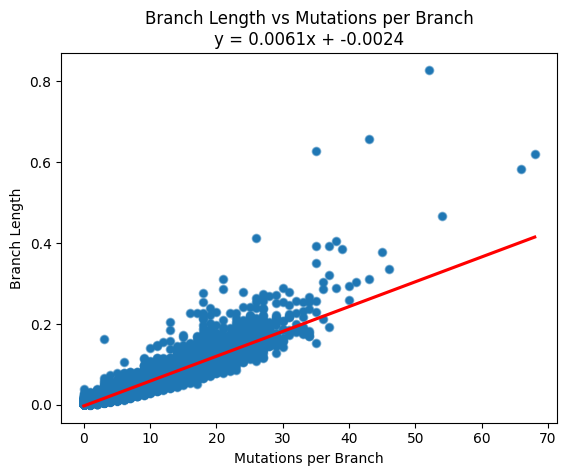

In [ ]:
# Can we use mutation per branch as a proxy for mutation rate? This could be useful for comparing to virus calculations from Jesse's lab.

df_branch_length_vs_mut_count = pd.merge(site_sub_probs_df_germline[['pcp_index', 'branch_length']].drop_duplicates(), site_sub_probs_df_germline[site_sub_probs_df_germline.mutation == True].groupby('pcp_index').size().reset_index(), how='left', on='pcp_index').fillna(0).rename(columns={0: 'mutations_per_branch'})

df_branch_length_vs_mut_count.plot(x='mutations_per_branch', y='branch_length', kind='scatter', title='Branch length vs mutations per branch')
# calculate regression line
sns.regplot(x='mutations_per_branch', y='branch_length', data=df_branch_length_vs_mut_count, scatter_kws={'alpha':0.5}, line_kws={'color':'red'}, ci=None)
plt.xlabel('Mutations per Branch')
plt.ylabel('Branch Length')
# get the regression line equation
slope, intercept = np.polyfit(df_branch_length_vs_mut_count['mutations_per_branch'], df_branch_length_vs_mut_count['branch_length'], 1)
print(f"Regression line: y = {slope:.4f}x + {intercept:.4f}")
plt.title('Branch Length vs Mutations per Branch\n' + f"y = {slope:.4f}x + {intercept:.4f}")


# Analysis by Branches


In [ ]:
## sanity check
trees_df[(trees_df['sample_id'] == 'sample-igg-SC-1') & (trees_df.family == 22)]

In [51]:
site_sub_probs_df_germline[(site_sub_probs_df_germline['sample_id'] == 'sample-igg-SC-1') & (site_sub_probs_df_germline.family ==22) & (site_sub_probs_df_germline.mutation == True)]

,neutral_prob,selection_factor,prob,mutation,pcp_index,site,is_cdr,parent_codon,parent_aa,child_codon,...,branch_length,parent_name,child_name,log_selection_factor,mutations_per_branch,germline_codon,germline_amino_acid,is_germline_aa,is_germline_codon,is_one_mutation_away
129259,0.067716,0.240985,0.016319,True,20615,6.0,False,GAG,E,CAG,...,0.024166,Node2,1ATCTCCGCAGGA,-1.423021,6,GAG,E,True,True,True
607365,0.141362,0.962552,0.136068,True,20617,29.0,True,ACC,T,AGA,...,0.033101,Node1,1CGCTTCCATGGA,-0.038168,6,ACC,T,True,True,False
680607,0.205888,0.756329,0.155719,True,20617,36.0,True,ACC,T,AAG,...,0.033101,Node1,1CGCTTCCATGGA,-0.279279,6,AGC,S,False,False,False
767532,0.023058,0.674371,0.015550,True,20614,40.0,False,ACC,T,GCC,...,0.007371,Node1,Node2,-0.393974,2,AGC,S,False,False,True
1115247,0.138928,0.269804,0.037483,True,20617,56.0,True,ATA,I,ACA,...,0.033101,Node1,1CGCTTCCATGGA,-1.310059,6,ATA,I,True,True,True
1180440,0.026125,0.463311,0.012104,True,20614,59.0,True,GAT,D,GGT,...,0.007371,Node1,Node2,-0.769356,2,GAT,D,True,True,True
1219753,0.118430,0.703241,0.083285,True,20615,63.0,True,AGT,S,AAT,...,0.024166,Node2,1ATCTCCGCAGGA,-0.352055,6,AGT,S,True,True,True
1241485,0.087481,1.389769,0.121579,True,20615,64.0,True,GAG,E,GAC,...,0.024166,Node2,1ATCTCCGCAGGA,0.329138,6,GAG,E,True,True,True
1241487,0.116277,1.494839,0.173815,True,20617,64.0,True,GAG,E,CAG,...,0.033101,Node1,1CGCTTCCATGGA,0.402019,6,GAG,E,True,True,True
1284949,0.139144,1.143301,0.159084,True,20615,66.0,False,TAC,Y,TTC,...,0.024166,Node2,1ATCTCCGCAGGA,0.133920,6,TAC,Y,True,True,True


In [10]:
compare_mutation_rates_on_different_backgrounds(site_sub_probs_df_germline[(site_sub_probs_df_germline['sample_id'] == 'sample-igg-SC-1') & (site_sub_probs_df_germline.family == 22)], 83, 64)

{'site1': 83,
 'site2': 64,
 'total_branch_counts': 3,
 'total_branch_length': np.float64(0.0373896704),
 'total_mutations_acquired': 1,
 'percent_of_removed_unresolved_pcps': 25.0,
 'has_site1_mutation_branch_count': 0,
 'has_site1_mutation_branch_length': np.float64(0.0),
 'has_site1_mutation_site2_acquired': 0,
 'has_site1_mutation_rate': 0.0,
 'no_site1_mutation_branch_count': 3,
 'no_site1_mutation_branch_length': np.float64(0.0373896704),
 'no_site1_mutation_site2_acquired': 1,
 'no_site1_mutation_rate': np.float64(26.74535478119647),
 'rate_ratio': np.float64(0.0),
 'log_rate_ratio': -inf,
 'rate_ratio_mutcount': np.float64(0.0),
 'log_rate_ratio_mutcount': -inf,
 'poisson_statistic': nan,
 'poisson_pvalue': nan,
 'poisson_statistic_mutcount': nan,
 'poisson_pvalue_mutcount': nan}

In [11]:
# test on whole df
compare_mutation_rates_on_different_backgrounds(
    site_sub_probs_df_germline, 108, 36)



{'site1': 108,
 'site2': 36,
 'total_branch_counts': 0,
 'total_branch_length': np.float64(0.0),
 'total_mutations_acquired': 0,
 'percent_of_removed_unresolved_pcps': 0,
 'has_site1_mutation_branch_count': 0,
 'has_site1_mutation_branch_length': np.float64(0.0),
 'has_site1_mutation_site2_acquired': 0,
 'has_site1_mutation_rate': 0.0,
 'no_site1_mutation_branch_count': 0,
 'no_site1_mutation_branch_length': np.float64(0.0),
 'no_site1_mutation_site2_acquired': 0,
 'no_site1_mutation_rate': 0.0,
 'rate_ratio': nan,
 'log_rate_ratio': nan,
 'rate_ratio_mutcount': nan,
 'log_rate_ratio_mutcount': nan,
 'poisson_statistic': nan,
 'poisson_pvalue': nan,
 'poisson_statistic_mutcount': nan,
 'poisson_pvalue_mutcount': nan}

In [12]:
compare_mutation_rates_on_different_backgrounds(site_sub_probs_df_germline, 50, 36)


{'site1': 50,
 'site2': 36,
 'total_branch_counts': 11591,
 'total_branch_length': np.float64(424.2615090218),
 'total_mutations_acquired': 2444,
 'percent_of_removed_unresolved_pcps': 0.6258573388203018,
 'has_site1_mutation_branch_count': 277,
 'has_site1_mutation_branch_length': np.float64(7.271639317),
 'has_site1_mutation_site2_acquired': 25,
 'has_site1_mutation_rate': np.float64(3.4380143060112673),
 'no_site1_mutation_branch_count': 11314,
 'no_site1_mutation_branch_length': np.float64(416.98986970479996),
 'no_site1_mutation_site2_acquired': 2419,
 'no_site1_mutation_rate': np.float64(5.801100160328799),
 'rate_ratio': np.float64(0.5926486719747319),
 'log_rate_ratio': np.float64(-0.5231535142846981),
 'rate_ratio_mutcount': np.float64(0.6132627143871527),
 'log_rate_ratio_mutcount': np.float64(-0.48896186326245045),
 'poisson_statistic': np.float64(-2.632132917249478),
 'poisson_pvalue': np.float64(0.008485066009937698),
 'poisson_statistic_mutcount': np.float64(-2.4565754195

In [ ]:
all_results = []
combinations = list(itertools.permutations([20,30,40,50,60,70,80.90], 2))
for site1, site2 in tqdm.tqdm(combinations):
    result = compare_mutation_rates_on_different_backgrounds(site_sub_probs_df_germline, site1, site2)
    all_results.append(result)

results_df = pd.DataFrame(all_results)

100%|██████████| 42/42 [00:06<00:00,  6.20it/s]


In [15]:
results_df

,site1,site2,total_branch_counts,total_branch_length,total_mutations_acquired,percent_of_removed_unresolved_pcps,has_site1_mutation_branch_count,has_site1_mutation_branch_length,has_site1_mutation_site2_acquired,has_site1_mutation_rate,...,no_site1_mutation_site2_acquired,no_site1_mutation_rate,rate_ratio,log_rate_ratio,rate_ratio_mutcount,log_rate_ratio_mutcount,poisson_statistic,poisson_pvalue,poisson_statistic_mutcount,poisson_pvalue_mutcount
0,20.0,30.0,19872,654.282375,831,0.245972,829,17.692154,10,0.565222,...,821,1.289684,0.438264,-0.824933,0.440881,-0.818979,-2.667074,7.651485e-03,-2.646757,8.126783e-03
1,20.0,40.0,15828,537.244783,1228,0.427781,612,13.361874,9,0.673558,...,1219,2.326856,0.289471,-1.239699,0.293378,-1.226293,-3.947323,7.902990e-05,-3.899394,9.643357e-05
2,20.0,50.0,21097,684.037957,313,0.132544,881,18.232758,9,0.493617,...,304,0.456590,1.081095,0.077974,1.079788,0.076764,0.230593,8.176308e-01,0.227014,8.204128e-01
3,20.0,60.0,802,24.066630,128,0.987654,15,0.165691,3,18.106018,...,125,5.229920,3.462007,1.241848,3.248250,1.178116,2.264832,2.352302e-02,2.135161,3.274790e-02
4,20.0,70.0,20088,660.910467,733,0.396668,765,17.004117,43,2.528799,...,690,1.071584,2.359870,0.858606,2.389714,0.871174,5.631966,1.781668e-08,5.719515,1.068283e-08
5,20.0,80.9,0,0.000000,0,0.000000,0,0.000000,0,0.000000,...,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,30.0,20.0,20746,675.834538,570,0.250024,1703,39.244317,36,0.917330,...,534,0.838844,1.093565,0.089443,1.103204,0.098219,0.519605,6.033386e-01,0.570629,5.682511e-01
7,30.0,40.0,15769,532.616812,1169,0.798943,1200,26.327089,39,1.481364,...,1130,2.231924,0.663716,-0.409901,0.662860,-0.411191,-2.534422,1.126330e-02,-2.542513,1.100585e-02
8,30.0,50.0,21091,683.751599,307,0.160947,1738,39.975263,19,0.475294,...,288,0.447360,1.062441,0.060569,1.068088,0.065870,0.255753,7.981415e-01,0.278144,7.809015e-01
9,30.0,60.0,803,24.016277,129,0.864198,34,0.601176,4,6.653630,...,125,5.338435,1.246363,0.220230,1.068346,0.066112,0.434454,6.639588e-01,0.130182,8.964226e-01


<Axes: xlabel='site2', ylabel='site1'>

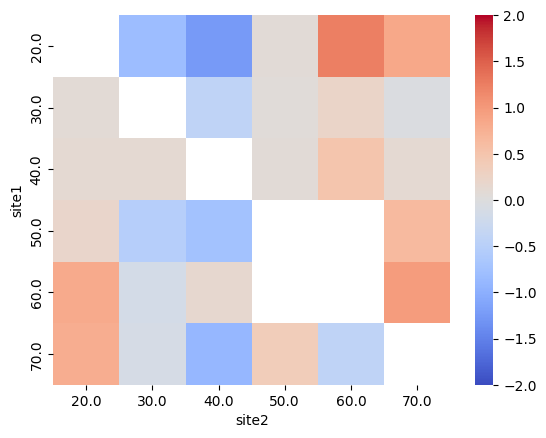

In [17]:
sns.heatmap(results_df.pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-2, vmax=2, cmap="coolwarm",)



In [ ]:
#### open big results
results_df = pd.read_csv(localify("EPISTASIS_EXPERIMENTS_DIR

In [ ]:
#### REPLOT THE DATA OF HOW MANY BRANCHES WERE THROWN OUT BECAUSE OF COMUTATIONS PER SITE PAIR

In [10]:
results_df = pd.read_csv('/home/nharel/re/dnsm-experiments-1/dnsm-train/_ignore/test_output/dnsm_1m-v1jaffe+v1tang-joint-ON-v1rodriguez-mutation_association_by_branch_length.csv')
results_df

,site1,site2,total_counts,total_branch_length,total_mutations_acquired,has_site1_mutation_count,has_site1_mutation_branch_length,has_site1_mutation_site2_acquired,has_site1_mutation_rate,no_site1_mutation_count,no_site1_mutation_branch_length,no_site1_mutation_site2_acquired,no_site1_mutation_rate,rate_ratio,log_rate_ratio,poisson_statistic,poisson_pvalue,valid_test
0,1.0,2.0,20357,673.562061,784,496,10.924770,22,2.013772,19861,662.637292,762,1.149950,1.751182,0.560291,2.624885,0.008668,True
1,1.0,3.0,19958,666.305260,1143,512,10.687363,31,2.900622,19446,655.617897,1112,1.696110,1.710162,0.536588,2.982282,0.002861,True
2,1.0,4.0,21152,689.873428,373,630,13.732358,7,0.509745,20522,676.141070,366,0.541307,0.941693,-0.060076,-0.157472,0.874873,True
3,1.0,5.0,20618,680.817441,700,577,12.791484,20,1.563540,20041,668.025958,680,1.017925,1.536008,0.429187,1.906317,0.056609,True
4,1.0,6.0,21205,692.581460,321,602,12.976575,11,0.847681,20603,679.604885,310,0.456147,1.858350,0.619689,2.052226,0.040148,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20587,128.0,123.0,0,0.000000,0,0,0.000000,0,0.000000,0,0.000000,0,0.000000,inf,NaN,NaN,NaN,False
20588,128.0,124.0,0,0.000000,0,0,0.000000,0,0.000000,0,0.000000,0,0.000000,inf,NaN,NaN,NaN,False
20589,128.0,125.0,0,0.000000,0,0,0.000000,0,0.000000,0,0.000000,0,0.000000,inf,NaN,NaN,NaN,False
20590,128.0,126.0,0,0.000000,0,0,0.000000,0,0.000000,0,0.000000,0,0.000000,inf,NaN,NaN,NaN,False


<Axes: xlabel='site2', ylabel='site1'>

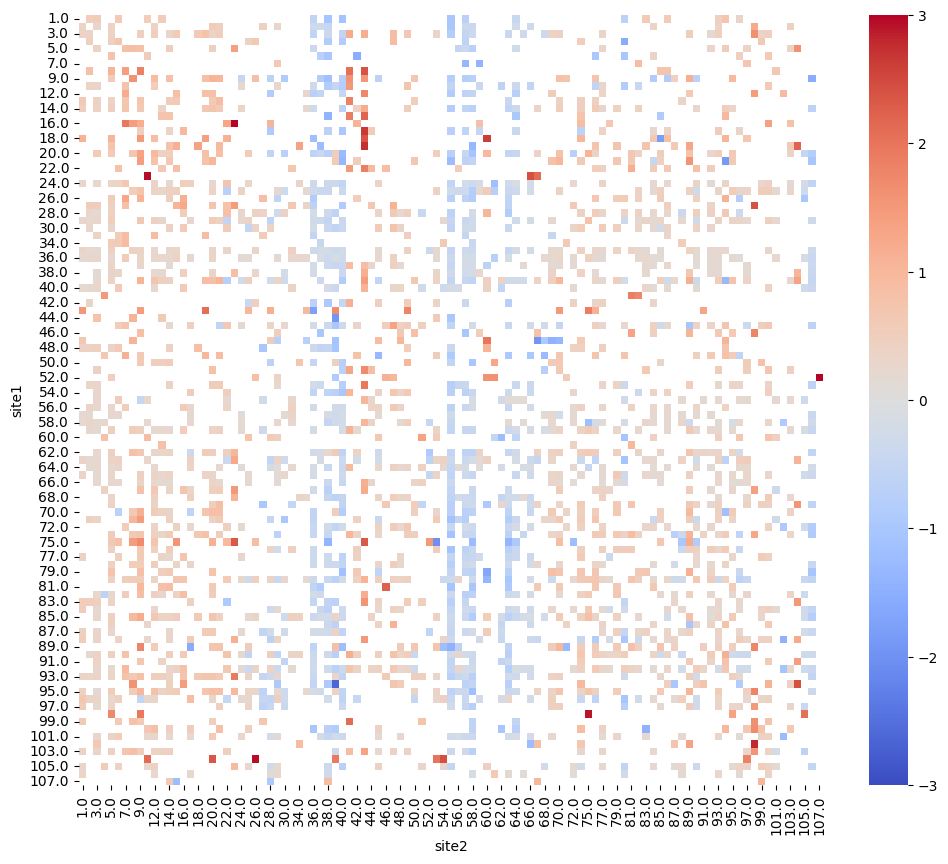

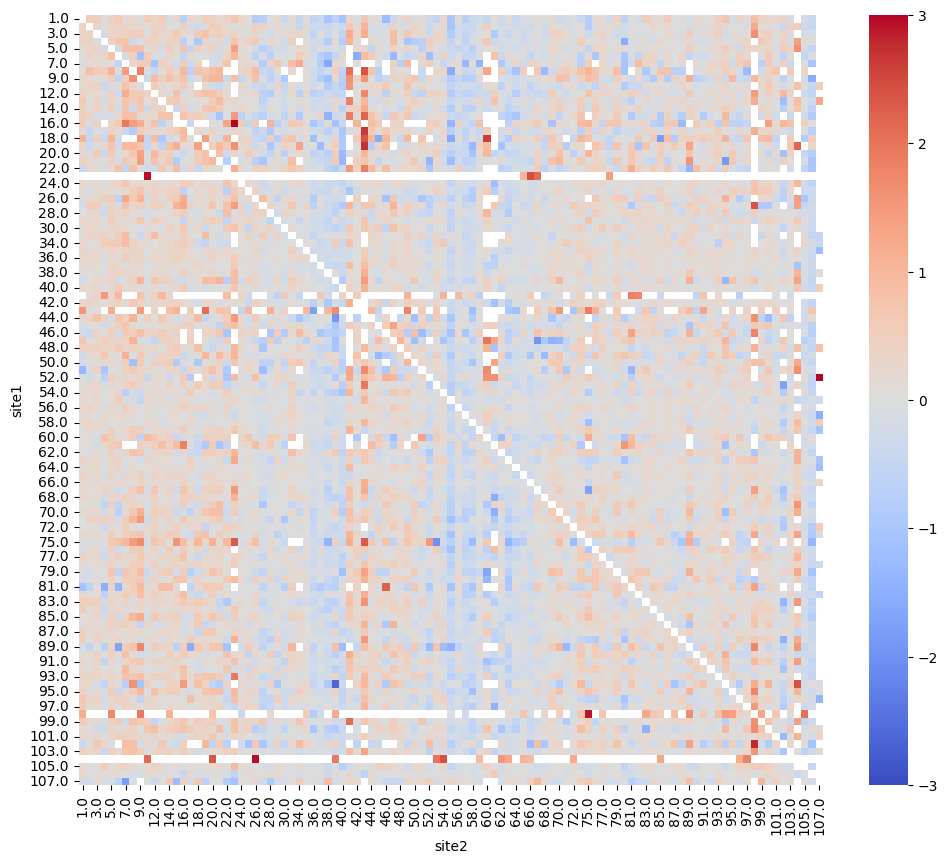

In [11]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df[(results_df.poisson_pvalue < 0.05)].pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-3, vmax=3, cmap="coolwarm", ax=ax)
fig, ax = plt.subplots(figsize=(12, 10))

sns.heatmap(results_df.pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-3, vmax=3, cmap="coolwarm", ax=ax)




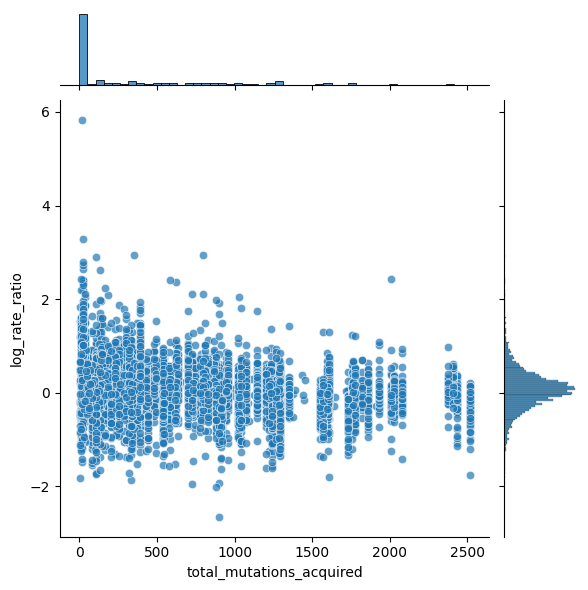

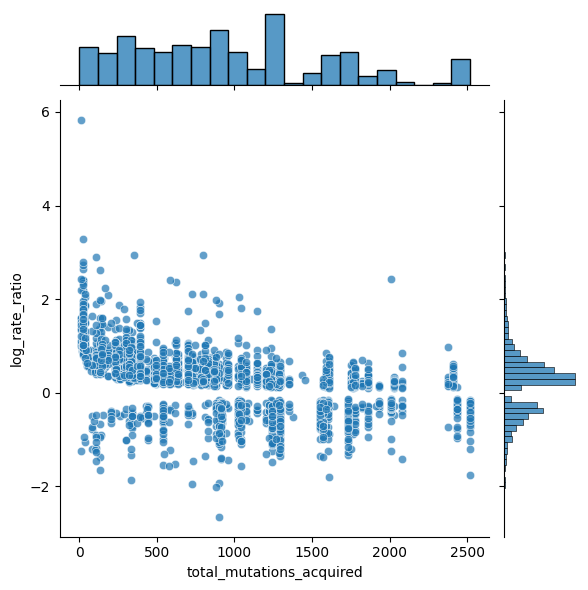

In [12]:
sns.jointplot(data=results_df, x='total_mutations_acquired', y='log_rate_ratio', alpha=0.7)
sns.jointplot(data=results_df[results_df.poisson_pvalue < 0.05], x='total_mutations_acquired', y='log_rate_ratio', alpha=0.7)



<Axes: xlabel='total_branch_length', ylabel='log_rate_ratio'>

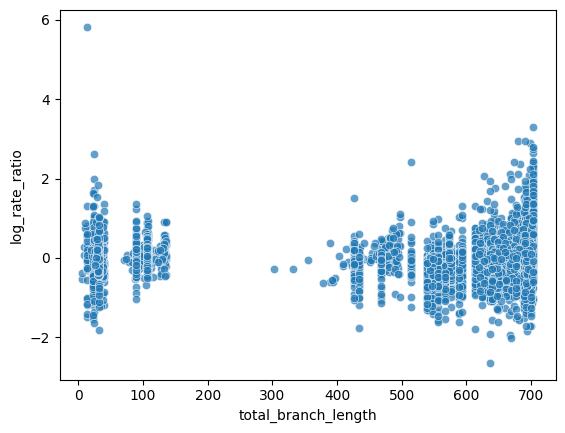

In [13]:
sns.scatterplot(data=results_df, x='total_branch_length', y='log_rate_ratio', alpha=0.7)

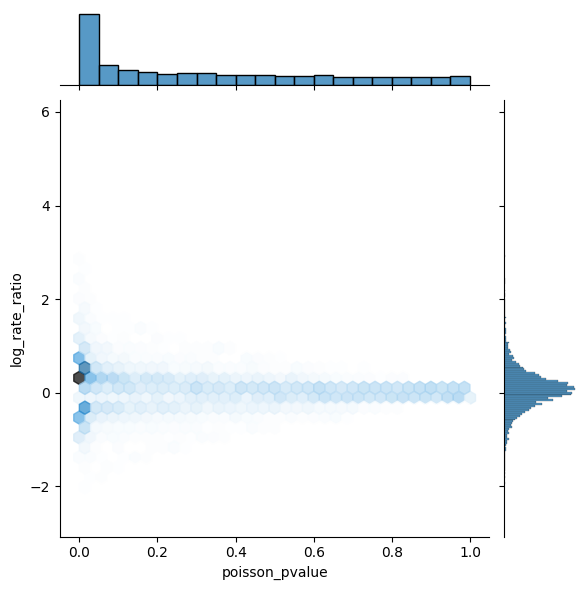

In [14]:
sns.jointplot(data=results_df, x='poisson_pvalue', y='log_rate_ratio', alpha=0.7, kind='hex')


<Axes: xlabel='site1', ylabel='log_rate_ratio'>

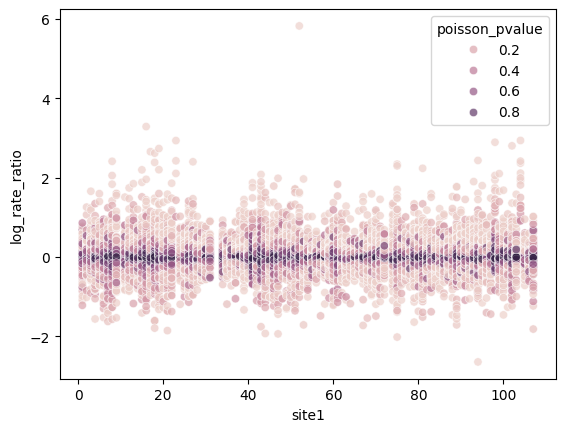

In [15]:
sns.scatterplot(data=results_df, x='site1', y='log_rate_ratio', alpha=0.7, hue='poisson_pvalue')


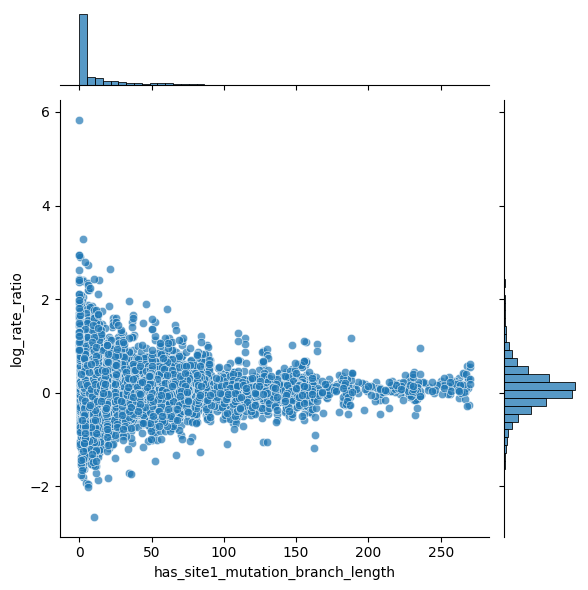

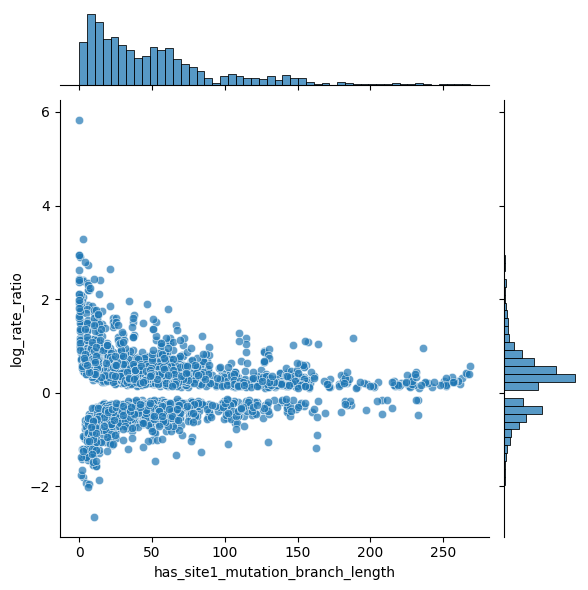

In [16]:
sns.jointplot(data=results_df, x='has_site1_mutation_branch_length', y='log_rate_ratio', alpha=0.7, marginal_kws=dict(bins=50))
sns.jointplot(data=results_df[results_df.poisson_pvalue < 0.05]
, x='has_site1_mutation_branch_length', y='log_rate_ratio', alpha=0.7, marginal_kws=dict(bins=50))



<Axes: xlabel='site1', ylabel='log_rate_ratio'>

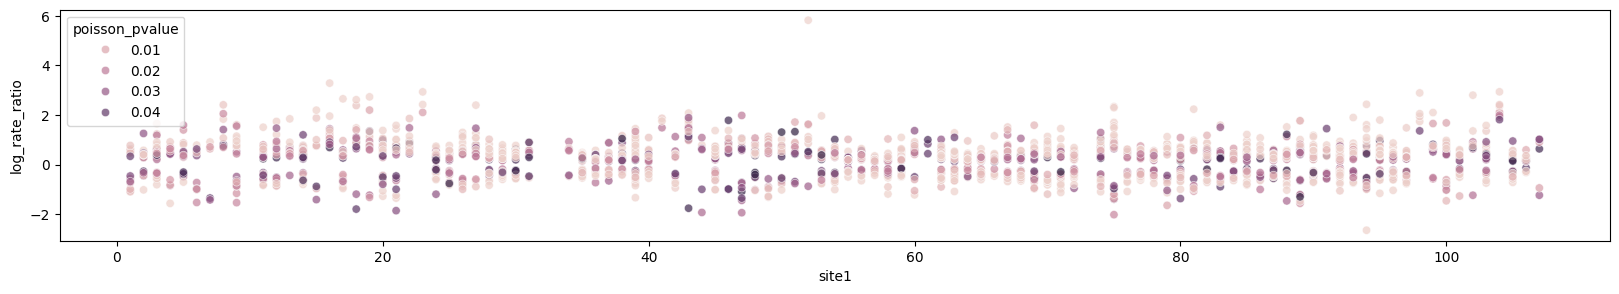

In [17]:
fig, ax = plt.subplots(figsize=(20, 3))
sns.scatterplot(data=results_df[results_df.poisson_pvalue < 0.05], x='site1', y='log_rate_ratio', alpha=0.7, hue='poisson_pvalue', ax=ax)


<Axes: >

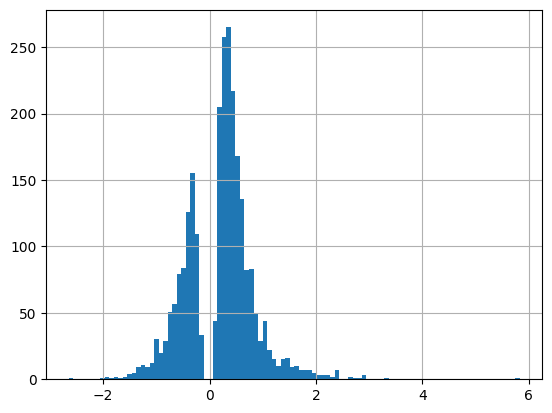

In [18]:
results_df[results_df.poisson_pvalue < 0.05].log_rate_ratio.hist(bins=100)

In [19]:
results_df[(results_df.poisson_pvalue < 0.05) & (results_df.has_site1_mutation_branch_length > 50)].sort_values(by='log_rate_ratio', ascending=False).head(20)

,site1,site2,total_counts,total_branch_length,total_mutations_acquired,has_site1_mutation_count,has_site1_mutation_branch_length,has_site1_mutation_site2_acquired,has_site1_mutation_rate,no_site1_mutation_count,no_site1_mutation_branch_length,no_site1_mutation_site2_acquired,no_site1_mutation_rate,rate_ratio,log_rate_ratio,poisson_statistic,poisson_pvalue,valid_test
12962,95.0,98.0,21709,703.295411,22,2594,60.776441,8,0.131630,19115,642.518970,14,0.021789,6.041053,1.798578,4.627672,3.697984e-06,True
14107,103.0,98.0,21709,703.295411,22,2107,50.411151,6,0.119021,19602,652.884260,16,0.024507,4.856695,1.580358,3.655688,2.564927e-04,True
11908,88.0,43.0,21698,702.806726,26,2305,52.338148,7,0.133746,19393,650.468578,19,0.029210,4.578808,1.521439,3.782695,1.551395e-04,True
5043,39.0,43.0,21698,702.806726,26,2581,66.364749,8,0.120546,19117,636.441977,18,0.028282,4.262249,1.449797,3.718710,2.002429e-04,True
5905,45.0,47.0,21427,697.073987,230,2142,50.298320,54,1.073595,19285,646.775667,176,0.272119,3.945311,1.372528,9.531909,1.544178e-21,True
14053,103.0,43.0,21698,702.806726,26,2108,50.413871,6,0.119015,19590,652.392855,20,0.030656,3.882222,1.356408,3.142615,1.674457e-03,True
5103,39.0,104.0,21730,703.704471,14,2602,66.832774,4,0.059851,19128,636.871697,10,0.015702,3.811733,1.338084,2.434326,1.491954e-02,True
8458,63.0,23.0,21729,703.696057,25,4357,109.836323,10,0.091045,17372,593.859734,15,0.025258,3.604513,1.282187,3.360306,7.785605e-04,True
11967,88.0,104.0,21730,703.704471,14,2307,52.440281,3,0.057208,19423,651.264189,11,0.016890,3.387043,1.219957,1.991328,4.644480e-02,True
11448,85.0,9.0,21115,691.482891,390,3400,83.935158,124,1.477331,17715,607.547733,266,0.437826,3.374244,1.216171,11.886569,1.390001e-32,True


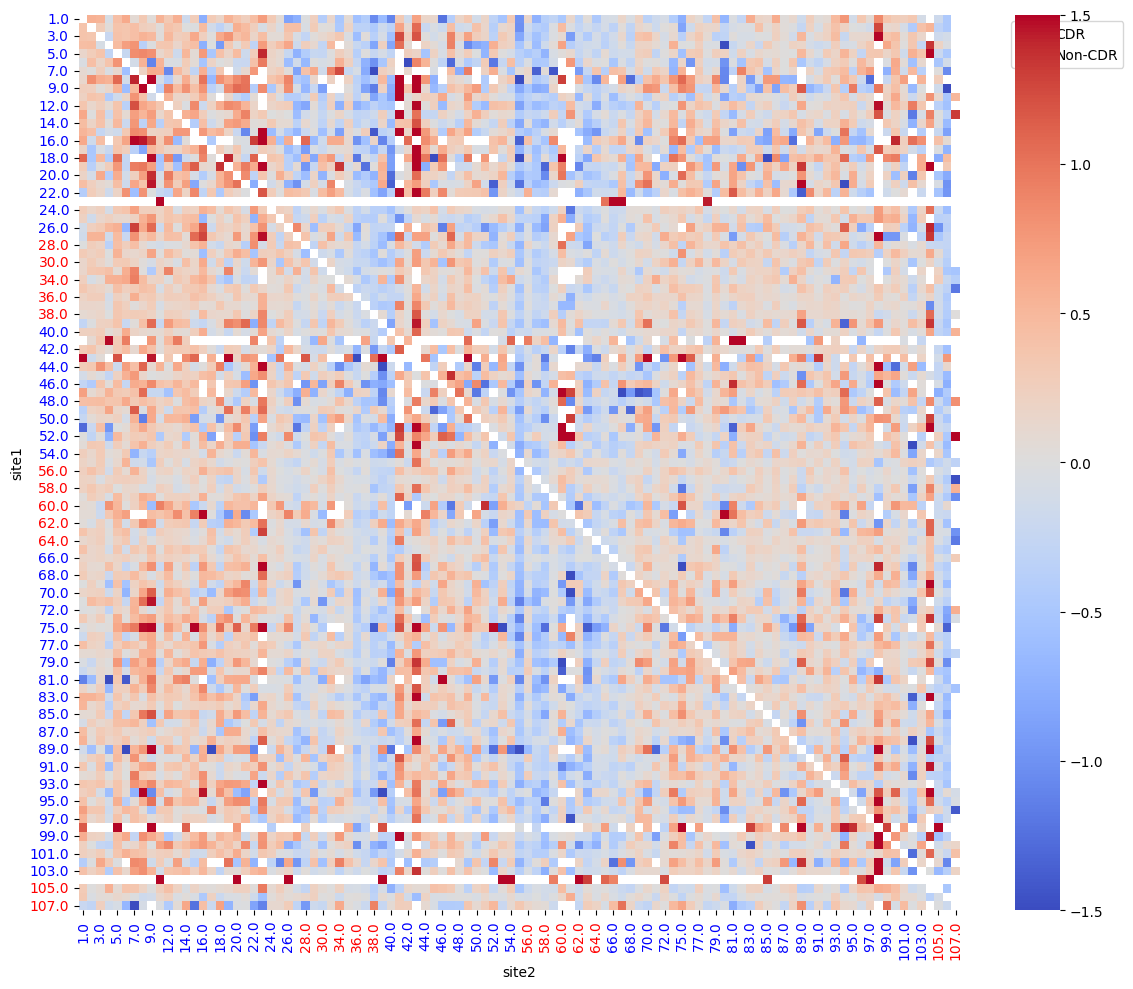

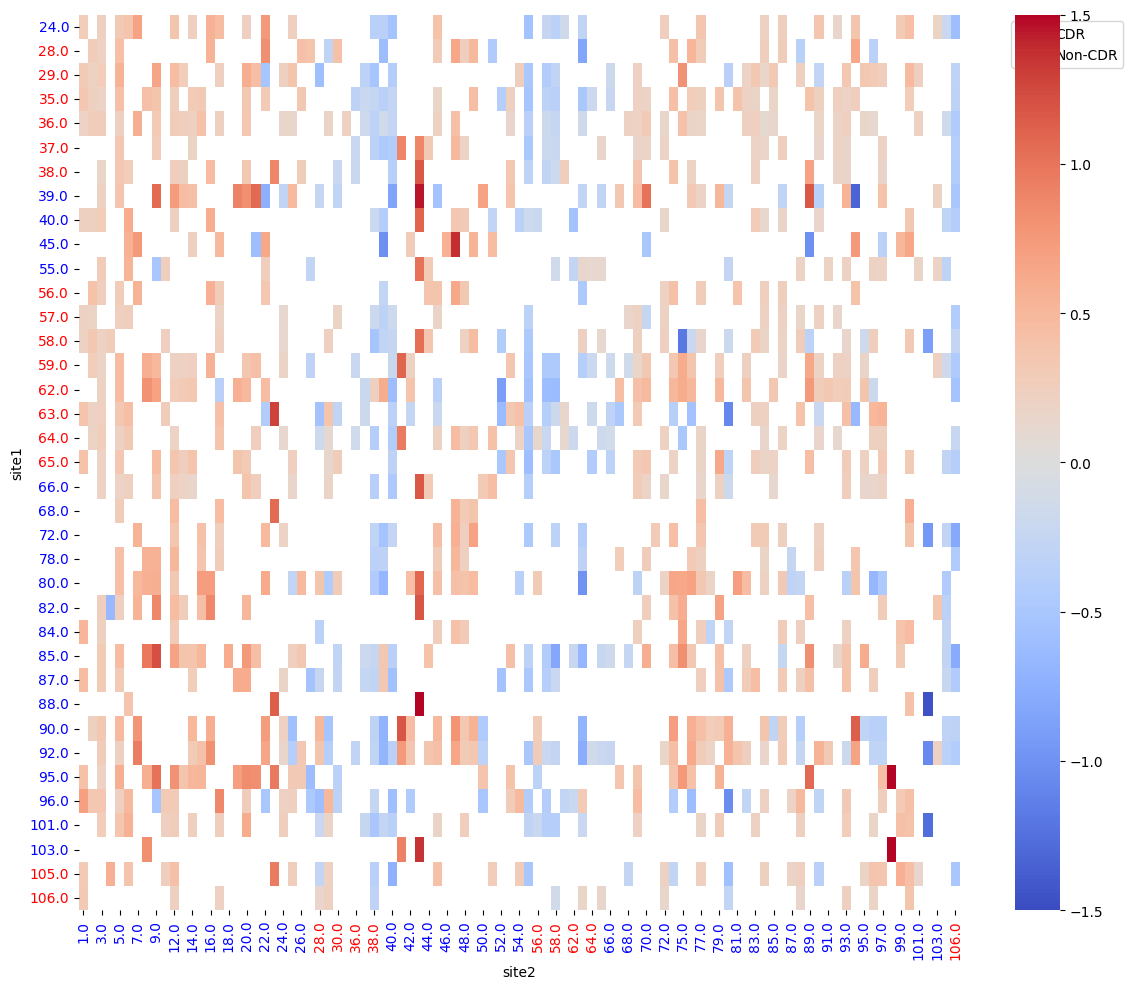

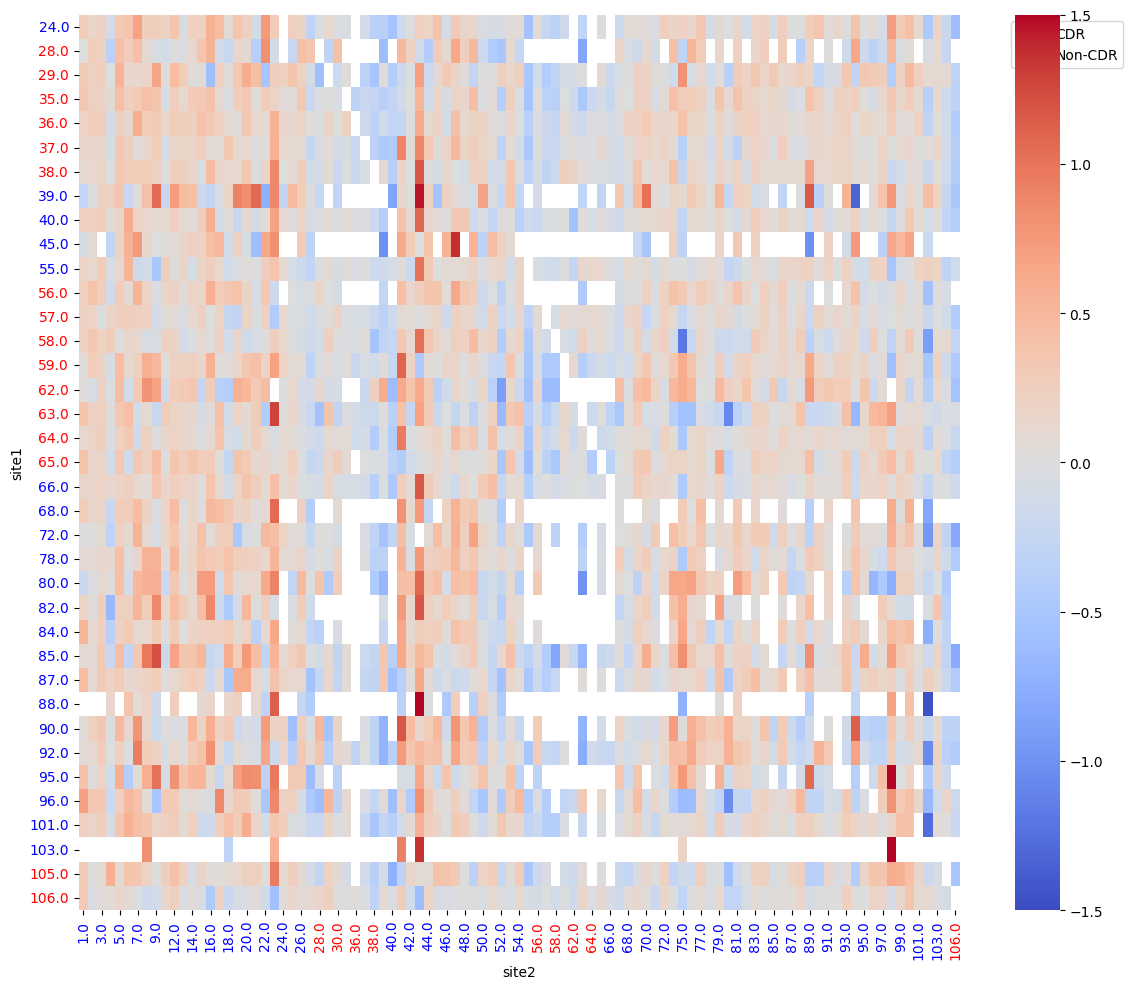

In [20]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df.pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-1.5, vmax=1.5, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df[(results_df.poisson_pvalue < 0.05) & (results_df.has_site1_mutation_branch_length > 50) & (results_df.total_mutations_acquired > 20)].pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-1.5, vmax=1.5, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df[(results_df.has_site1_mutation_branch_length > 50) & (results_df.total_mutations_acquired > 20)].pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-1.5, vmax=1.5, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


In [32]:
results_df[(results_df.site1 == 85) & (results_df.site2 == 9)].T


,11448
site1,85.0
site2,9.0
total_counts,21115
total_branch_length,691.482891
total_mutations_acquired,390
has_site1_mutation_count,3400
has_site1_mutation_branch_length,83.935158
has_site1_mutation_site2_acquired,124
has_site1_mutation_rate,1.477331
no_site1_mutation_count,17715


In [22]:
results_df[(results_df.site1 == 63) & (results_df.site2 == 23)].T


### are these effects not because of epistasis, bu tbecause of CDR FWR tendencies?
# For example, site 63 is in CDR3, and site 23 is in FWR3.
# This shows that a mutation at 23 is 3.6 times more likely to occur after a mutation at 63, how can i separate between epistasis and 
# the fact that CDR sites tend to mutate earlier in the lineage, and FWR later?



,8458
site1,63.0
site2,23.0
total_counts,21729
total_branch_length,703.696057
total_mutations_acquired,25
has_site1_mutation_count,4357
has_site1_mutation_branch_length,109.836323
has_site1_mutation_site2_acquired,10
has_site1_mutation_rate,0.091045
no_site1_mutation_count,17372


In [23]:
results_df[(results_df.site1 == 39) & (results_df.site2 == 9)].T
# 9 is FR1, and 39 is the first site after CDR1.
# site 9 mutation is 2.9 times more likely to occur after a mutation at site 39 then when it's not mutated.
# this again could be because of CDR vs FWR tendencies, or because of epistasis.
# but it is interesting that other CDR sites don't have this effect on site 9.
# for example, mutations at sites 23, 41 and 43 occur more on the background of many other mutations in general, but for site 9 this is more specific.
# Let's try normalizing every column



,5013
site1,39.0
site2,9.0
total_counts,21115
total_branch_length,691.482891
total_mutations_acquired,390
has_site1_mutation_count,2356
has_site1_mutation_branch_length,62.564374
has_site1_mutation_site2_acquired,87
has_site1_mutation_rate,1.390568
no_site1_mutation_count,18759


In [24]:
results_df[(results_df.site1 == 58) & (results_df.site2 == 75)].T


### are these effects not because of epistasis, bu tbecause of CDR FWR tendencies?



,7791
site1,58.0
site2,75.0
total_counts,21507
total_branch_length,697.964814
total_mutations_acquired,106
has_site1_mutation_count,6273
has_site1_mutation_branch_length,162.649194
has_site1_mutation_site2_acquired,9
has_site1_mutation_rate,0.055334
no_site1_mutation_count,15234


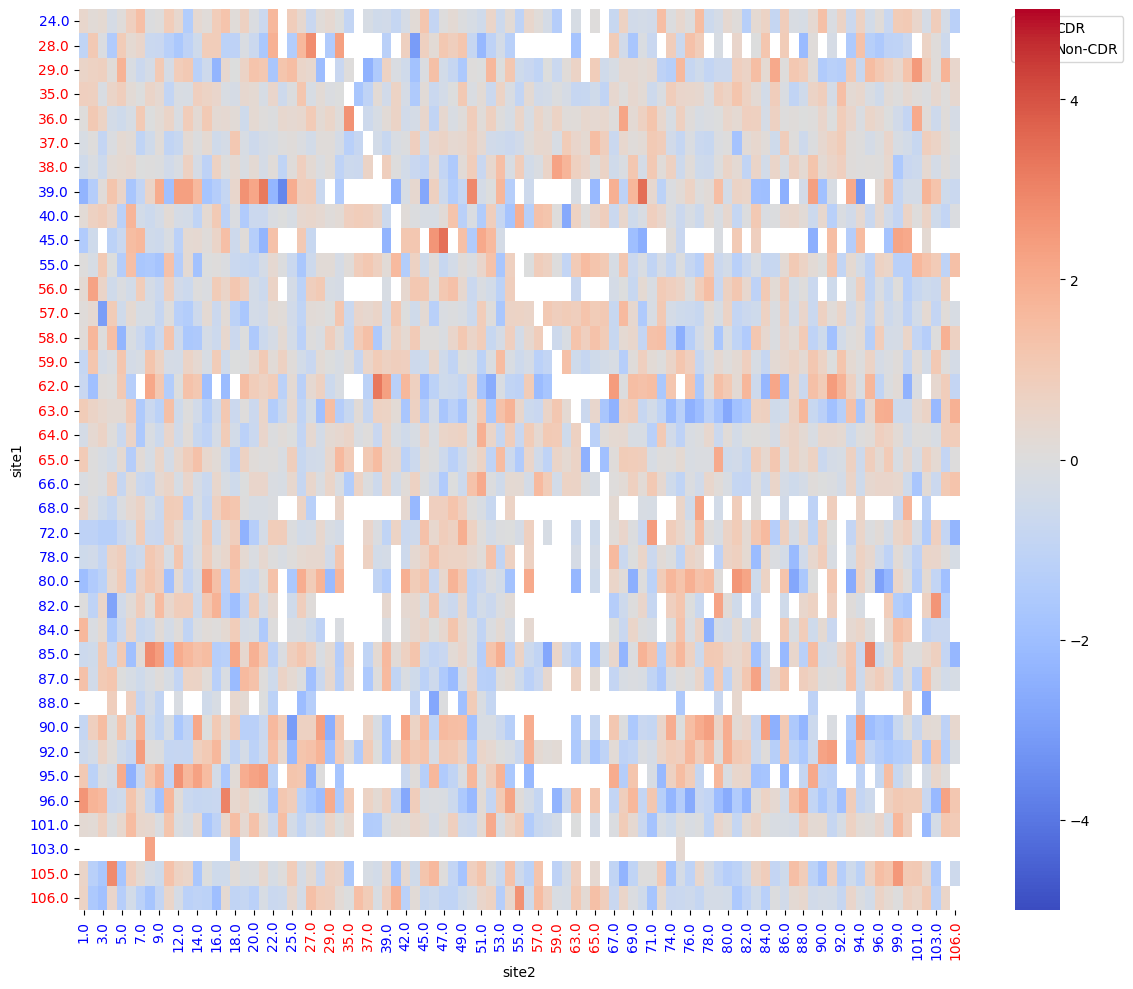

In [25]:
pythonfig, ax = plt.subplots(figsize=(12, 10))

# Create pivot table
pivot_data = results_df[(results_df.has_site1_mutation_branch_length > 50) & (results_df['total_mutations_acquired'] > 100)].pivot_table(
    index='site1', 
    columns='site2', 
    values='log_rate_ratio'
)

# Normalize columns
pivot_normalized = (pivot_data - pivot_data.mean(axis=0)) / pivot_data.std(axis=0)

# Create the heatmap
sns.heatmap(pivot_normalized, vmin=-5, vmax=5, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

In [92]:
results_df[(results_df.site1 == 62) & (results_df.site2 == 38)].T
# 9 is FR1, and 39 is the first site after CDR1.
# site 9 mutation is 2.9 times more likely to occur after a mutation at site 39.
# this again could be because of CDR vs FWR tendencies, or because of epistasis.
# but it is interesting that other CDR sites don't have this effect on site 9.
# for example, mutations at sites 23, 41 and 43 occur more on the background of many other mutations in general, but for site 8 this is more specific.
# Let's try normalizing every column



,8328
site1,62.0
site2,38.0
total_counts,12006
total_branch_length,413.63319
total_mutations_acquired,653
has_site1_mutation_count,1767
has_site1_mutation_branch_length,50.097242
has_site1_mutation_site2_acquired,96
has_site1_mutation_rate,1.916273
no_site1_mutation_count,10239


In [71]:
def test_directionality(results_df, site_a, site_b):
    """
    Test if site_a → site_b is preferred over site_b → site_a
    """
    # Get results for both directions
    result_a_to_b = results_df[
        (results_df['site1'] == site_a) & (results_df['site2'] == site_b)
    ]
    result_b_to_a = results_df[
        (results_df['site1'] == site_b) & (results_df['site2'] == site_a)
    ]
    
    if len(result_a_to_b) == 0 or len(result_b_to_a) == 0:
        return None
    
    # Extract the key metrics
    rate_a_to_b = result_a_to_b['has_site1_mutation_rate'].iloc[0]
    rate_b_to_a = result_b_to_a['has_site1_mutation_rate'].iloc[0]
    
    # Compare the rates directly
    rate_ratio_directional = rate_a_to_b / rate_b_to_a if rate_b_to_a > 0 else np.inf
    
    # Statistical test comparing the two rates
    # Use the counts and exposures for both directions
    count_a_to_b = result_a_to_b['has_site1_mutation_site2_acquired'].iloc[0]
    exposure_a_to_b = result_a_to_b['has_site1_mutation_branch_length'].iloc[0]
    
    count_b_to_a = result_b_to_a['has_site1_mutation_site2_acquired'].iloc[0]
    exposure_b_to_a = result_b_to_a['has_site1_mutation_branch_length'].iloc[0]
    
    # Test if the two directional rates are significantly different
    try:
        if exposure_a_to_b > 0 and exposure_b_to_a > 0:
            directional_result = test_poisson_2indep(
                count1=count_a_to_b,
                exposure1=exposure_a_to_b,
                count2=count_b_to_a,
                exposure2=exposure_b_to_a
            )
            directional_pvalue = directional_result.pvalue
            directional_statistic = directional_result.statistic
        else:
            directional_pvalue = np.nan
            directional_statistic = np.nan
    except:
        directional_pvalue = np.nan
        directional_statistic = np.nan
    
    return {
        'site_a': site_a,
        'site_b': site_b,
        'rate_a_to_b': rate_a_to_b,
        'rate_b_to_a': rate_b_to_a,
        'rate_ratio_directional': rate_ratio_directional,
        'directional_statistic': directional_statistic,
        'directional_pvalue': directional_pvalue,
        'preferred_direction': 'A→B' if rate_a_to_b > rate_b_to_a else 'B→A',
        'is_directional': directional_pvalue < 0.05 if not np.isnan(directional_pvalue) else False
    }


# Test directionality for all unique pairs
import itertools

directional_results = []
unique_sites = sorted(results_df['site1'].unique())

for site_a, site_b in itertools.combinations(unique_sites, 2):
    result = test_directionality(results_df, site_a, site_b)
    if result:
        directional_results.append(result)

directional_df = pd.DataFrame(directional_results)

# Filter for significant directional preferences
significant_directional = directional_df[
    (directional_df['is_directional'] == True) & 
    (directional_df['rate_ratio_directional'] > 2)  # Strong preference
]

print(f"Found {len(significant_directional)} significant directional preferences")

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/statsmodels/stats/rates.py:870: RuntimeWarning: divide by zero encountered in scalar divide
  ratio = rate1 / rate2
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/statsmodels/stats/rates.py:776: RuntimeWarning: invalid value encountered in scalar divide
  stat = (y1 - y2 * r_d) / np.sqrt((y1 + y2) * r_d)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/statsmodels/stats/rates.py:870: RuntimeWarning: invalid value encountered in scalar divide
  ratio = rate1 / rate2


Found 1467 significant directional preferences


<Axes: >

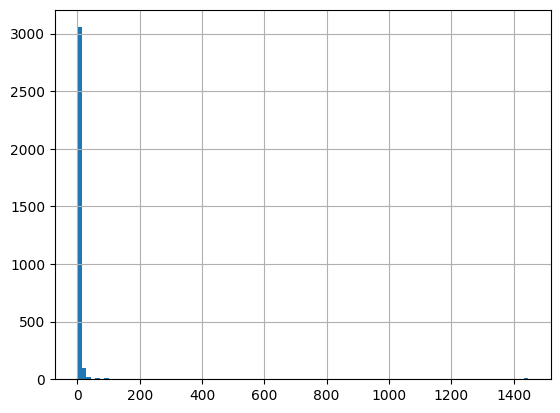

In [ ]:
directional_df_plot = directional_df[directional_df.directional_pvalue < 0.05].copy()
max_finite = directional_df_plot['rate_ratio_directional'].replace([np.inf, -np.inf], np.nan).max()
directional_df_plot['rate_ratio_directional'] = directional_df_plot['rate_ratio_directional'].replace([np.inf, -np.inf], max_finite)
directional_df_plot.sort_values(by='rate_ratio_directional', ascending=False)['rate_ratio_directional'].hist(bins=100)

<Axes: >

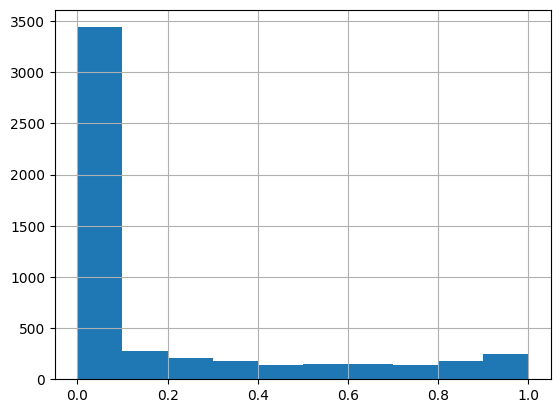

In [82]:
directional_df.directional_pvalue.hist()

/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


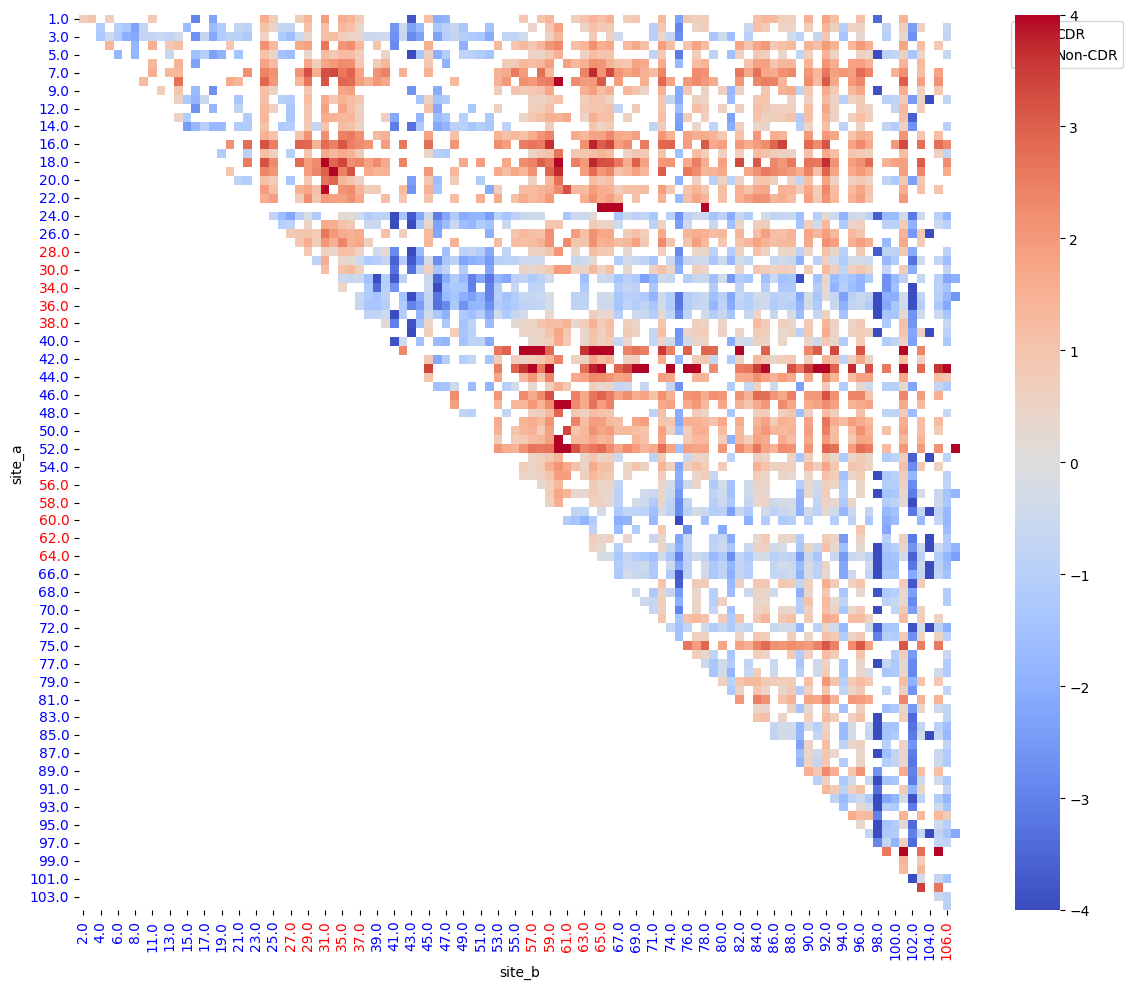

In [88]:

fig, ax = plt.subplots(figsize=(12, 10))
directional_df['log_rate_ratio_directional'] = np.log(directional_df['rate_ratio_directional'])
sns.heatmap(directional_df[directional_df.directional_pvalue < 0.05].pivot_table(index='site_a', columns='site_b', values='log_rate_ratio_directional'), vmin=-4, vmax=4, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


In [38]:
## How often do mutations happen on the same branch?

site_sub_probs_df_germline[site_sub_probs_df_germline.mutation == True].groupby('pcp_index').size().sort_values(ascending=False)

pcp_index
17324    68
15468    66
13495    54
4669     52
7129     46
         ..
7307      1
7306      1
7299      1
7327      1
21727     1
Length: 19703, dtype: int64

Text(0, 0.5, 'Count of branches')

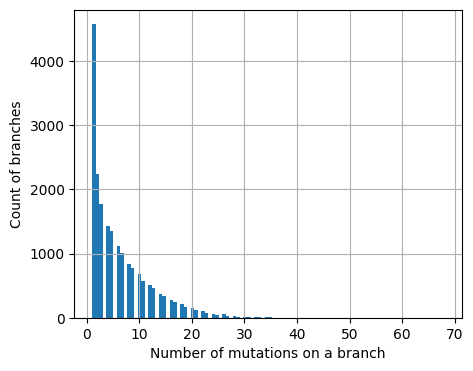

In [42]:
fig, ax = plt.subplots(figsize=(5, 4))
site_sub_probs_df_germline[site_sub_probs_df_germline.mutation == True].groupby('pcp_index').size().hist(bins=100)
ax.set_xlabel('Number of mutations on a branch')
ax.set_ylabel('Count of branches')

Total site pairs with co-mutations: 8535

Top 10 most frequent co-mutations:
      site1  site2  comutation_count
25     36.0   64.0              1033
647    35.0   36.0               921
50     64.0   66.0               884
2420   36.0   58.0               795
1345   59.0   64.0               794
254    36.0   92.0               790
1753   64.0   92.0               781
26     36.0   66.0               781
1155   35.0   64.0               781
249    36.0   59.0               769


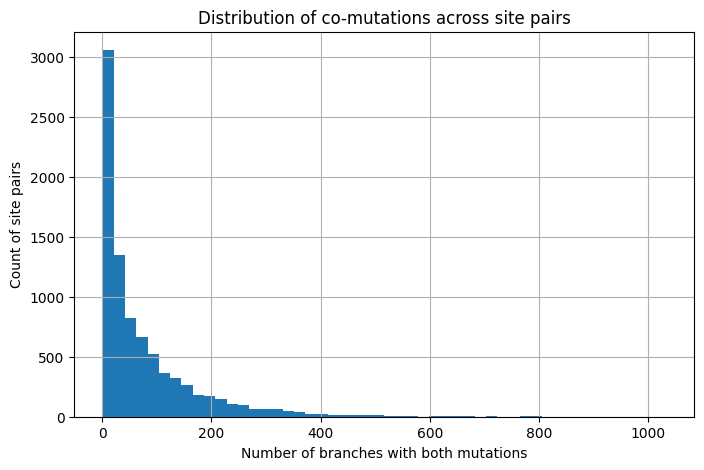

In [10]:
def count_branch_comutations(site_sub_probs_df_germline):
    """
    Count how often pairs of sites mutate on the same branch
    """
    # Get mutations per branch
    mutations_per_branch = (
        site_sub_probs_df_germline[site_sub_probs_df_germline.mutation == True]
        .groupby('pcp_index')['site']
        .apply(list)
        .reset_index()
    )
    
    # Count co-mutations for each pair
    from itertools import combinations
    
    comutation_counts = {}
    
    for _, row in mutations_per_branch.iterrows():
        sites = row['site']
        if len(sites) >= 2:  # Only branches with 2+ mutations
            for site1, site2 in combinations(sorted(sites), 2):
                pair = (site1, site2)
                comutation_counts[pair] = comutation_counts.get(pair, 0) + 1
    
    return comutation_counts

# Get co-mutation counts
comutation_counts = count_branch_comutations(site_sub_probs_df_germline)

# Convert to DataFrame
comutation_df = pd.DataFrame([
    {'site1': pair[0], 'site2': pair[1], 'comutation_count': count}
    for pair, count in comutation_counts.items()
])

# Sort by frequency
comutation_df = comutation_df.sort_values('comutation_count', ascending=False)

print(f"Total site pairs with co-mutations: {len(comutation_df)}")
print("\nTop 10 most frequent co-mutations:")
print(comutation_df.head(10))

# Plot distribution
fig, ax = plt.subplots(figsize=(8, 5))
comutation_df['comutation_count'].hist(bins=50, ax=ax)
ax.set_xlabel('Number of branches with both mutations')
ax.set_ylabel('Count of site pairs')
ax.set_title('Distribution of co-mutations across site pairs')
plt.show()

Top 10 site pairs with highest co-mutation percentages:
      site1  site2  comutation_count  independent_mutations  \
920   108.0  109.0               561                   2056   
533   107.0  108.0               456                   1694   
547   108.0  114.0               476                   2044   
25     36.0   64.0              1033                   4607   
50     64.0   66.0               884                   3993   
2374  107.0  109.0               359                   1726   
647    35.0   36.0               921                   4500   
2420   36.0   58.0               795                   4020   
921   109.0  114.0               400                   2034   
539   107.0  114.0               319                   1624   

      comutation_percentage  
920               21.436760  
533               21.209302  
547               18.888889  
25                18.315603  
50                18.125897  
2374              17.218225  
647               16.989485  
2420      

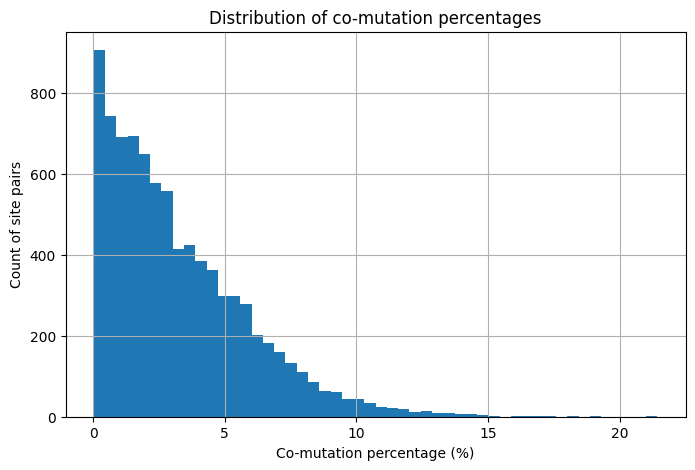


Summary statistics:
Mean co-mutation percentage: 3.26%
Median co-mutation percentage: 2.61%
Max co-mutation percentage: 21.44%


In [11]:
def calculate_comutation_percentages(site_sub_probs_df_germline):
    """
    Calculate what percentage of site pair mutations occur on the same branch
    vs. on different branches
    """
    from itertools import combinations
    
    # Get mutations per branch
    mutations_per_branch = (
        site_sub_probs_df_germline[site_sub_probs_df_germline.mutation == True]
        .groupby('pcp_index')['site']
        .apply(list)
        .reset_index()
    )
    
    # Count co-mutations (same branch)
    comutation_counts = {}
    for _, row in mutations_per_branch.iterrows():
        sites = row['site']
        if len(sites) >= 2:
            for site1, site2 in combinations(sorted(sites), 2):
                pair = (site1, site2)
                comutation_counts[pair] = comutation_counts.get(pair, 0) + 1
    
    # Count total mutations per site
    site_mutation_counts = (
        site_sub_probs_df_germline[site_sub_probs_df_germline.mutation == True]
        .groupby('site')
        .size()
        .to_dict()
    )
    
    # Calculate percentages
    results = []
    for pair, comutation_count in comutation_counts.items():
        site1, site2 = pair
        
        # Total mutations at each site
        total_site1 = site_mutation_counts.get(site1, 0)
        total_site2 = site_mutation_counts.get(site2, 0)
        
        # Independent mutations (total - co-mutations)
        independent_mutations = total_site1 + total_site2 - (2 * comutation_count)
        
        # Calculate percentage
        total_pair_mutations = comutation_count + independent_mutations
        comutation_percentage = (comutation_count / total_pair_mutations * 100) if total_pair_mutations > 0 else 0
        
        results.append({
            'site1': site1,
            'site2': site2,
            'comutation_count': comutation_count,
            'independent_mutations': independent_mutations,
            'total_pair_mutations': total_pair_mutations,
            'comutation_percentage': comutation_percentage,
            'site1_total_mutations': total_site1,
            'site2_total_mutations': total_site2
        })
    
    return pd.DataFrame(results)

# Calculate percentages
comutation_percentages = calculate_comutation_percentages(site_sub_probs_df_germline)

# Sort by percentage
comutation_percentages = comutation_percentages.sort_values('comutation_percentage', ascending=False)

print("Top 10 site pairs with highest co-mutation percentages:")
print(comutation_percentages.head(10)[['site1', 'site2', 'comutation_count', 'independent_mutations', 'comutation_percentage']])

# Plot distribution
fig, ax = plt.subplots(figsize=(8, 5))
comutation_percentages['comutation_percentage'].hist(bins=50, ax=ax)
ax.set_xlabel('Co-mutation percentage (%)')
ax.set_ylabel('Count of site pairs')
ax.set_title('Distribution of co-mutation percentages')
plt.show()

# Summary statistics
print(f"\nSummary statistics:")
print(f"Mean co-mutation percentage: {comutation_percentages['comutation_percentage'].mean():.2f}%")
print(f"Median co-mutation percentage: {comutation_percentages['comutation_percentage'].median():.2f}%")
print(f"Max co-mutation percentage: {comutation_percentages['comutation_percentage'].max():.2f}%")

In [15]:
results_df = pd.read_csv('/home/nharel/data/epistasis/mutation_rates_on_different_backgrounds/mutation_rates_on_different_backgrounds_v1rodriguez_v1tang_20250720_185956.csv')

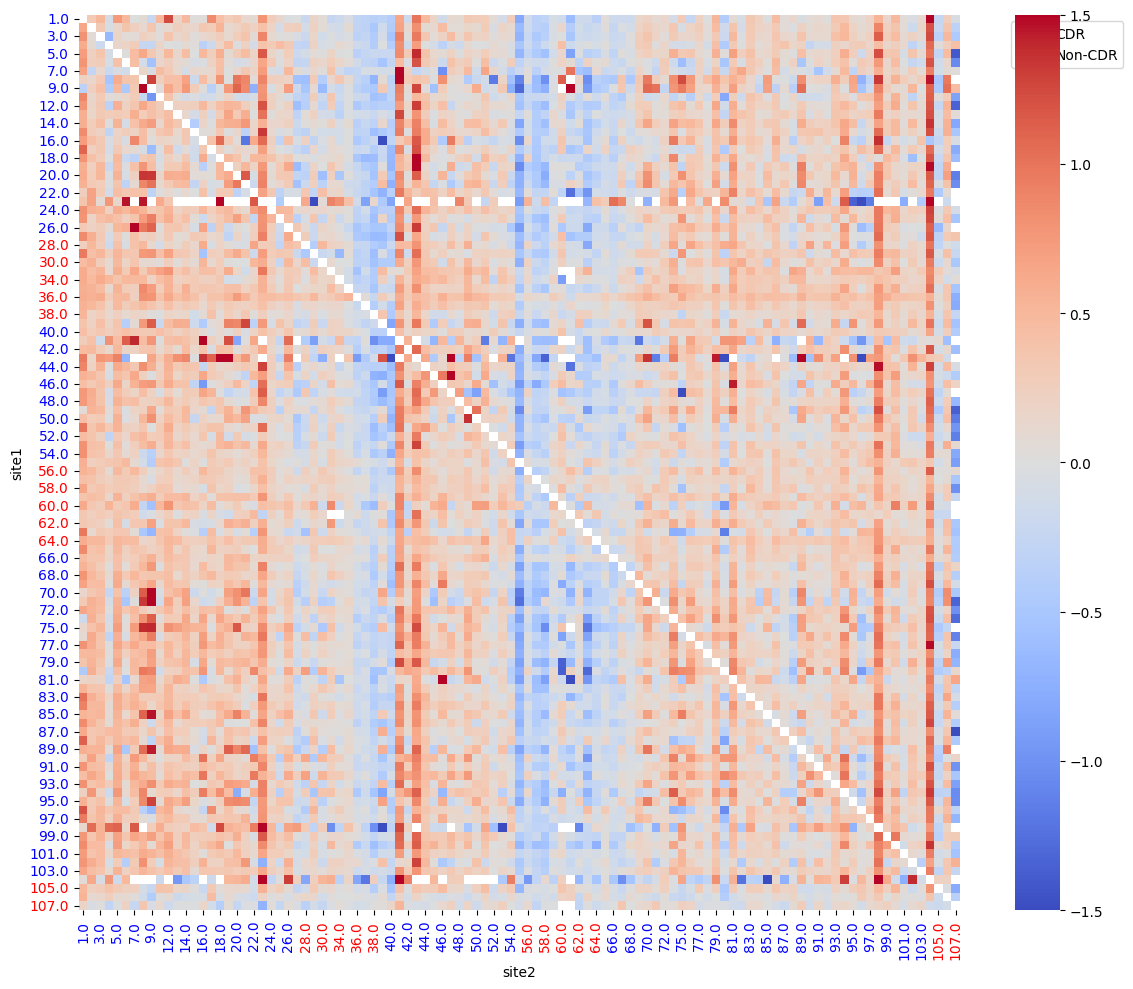

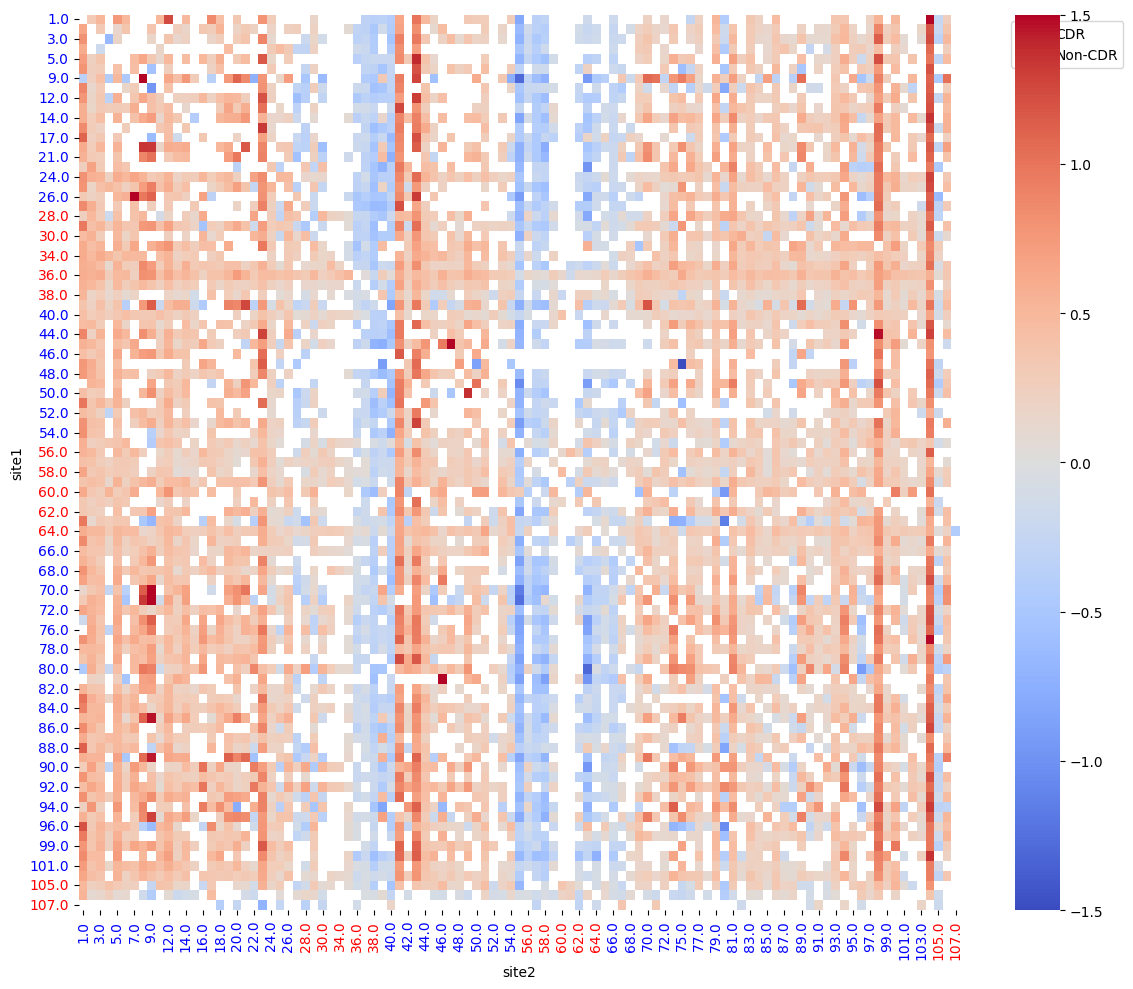

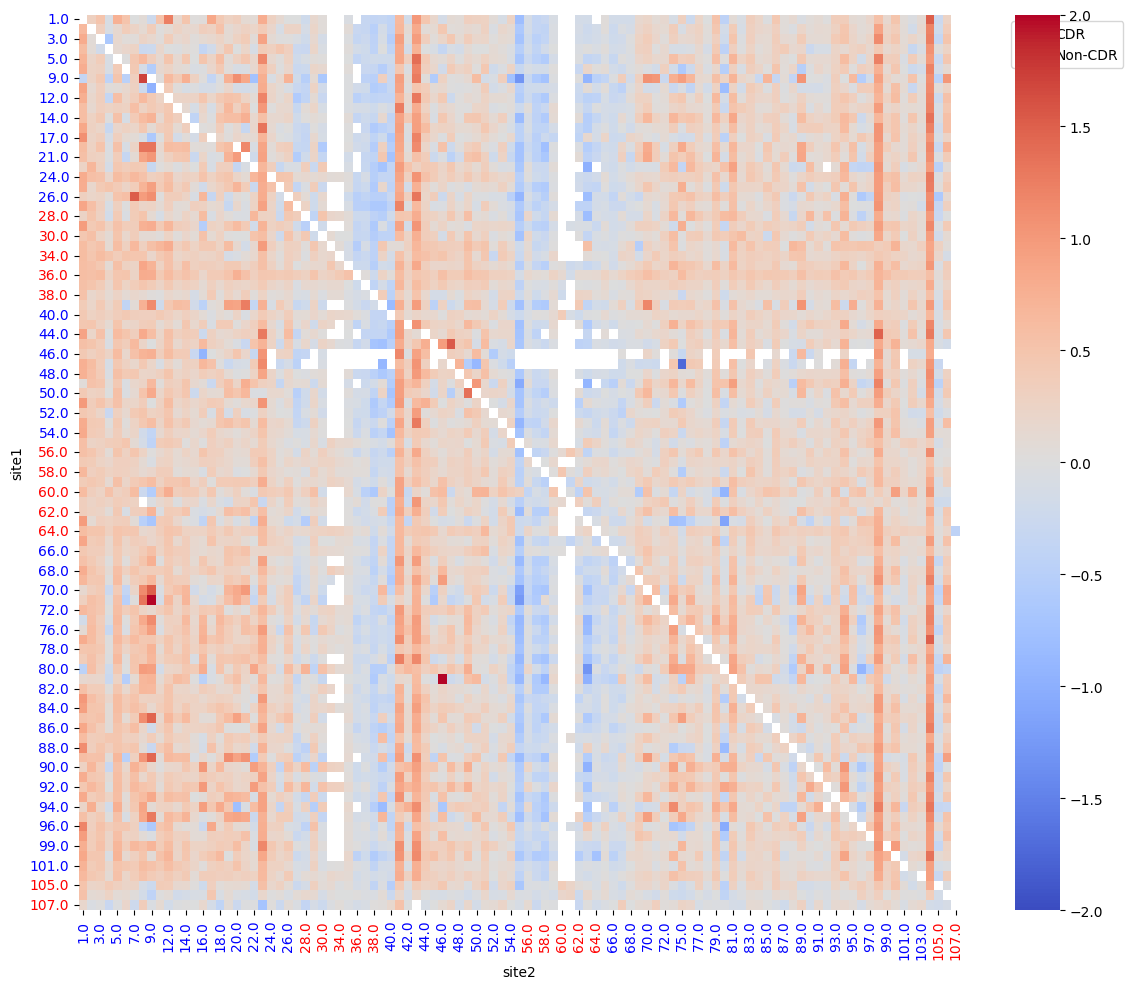

In [17]:
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df.pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-1.5, vmax=1.5, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df[(results_df.poisson_pvalue < 0.05) & (results_df.has_site1_mutation_branch_length > 50) & (results_df.total_mutations_acquired > 20)].pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-1.5, vmax=1.5, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df[(results_df.has_site1_mutation_branch_length > 50) & (results_df.total_mutations_acquired > 20)].pivot_table(index='site1', columns='site2', values='log_rate_ratio'), vmin=-2, vmax=2, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()


In [27]:
results_df.head().T

,0,1,2,3,4
site1,1.000000,1.000000,1.000000,1.000000,1.000000
site2,2.000000,3.000000,4.000000,5.000000,6.000000
total_branch_counts,20251.000000,19867.000000,21102.000000,20568.000000,21159.000000
total_branch_length,663.044982,655.630979,683.622302,673.761628,686.017671
total_mutations_acquired,678.000000,1052.000000,323.000000,650.000000,275.000000
percent_of_removed_unresolved_pcps,0.520705,0.455958,0.236384,0.242507,0.216930
has_site1_mutation_branch_count,493.000000,509.000000,626.000000,574.000000,600.000000
has_site1_mutation_branch_length,10.701610,10.572840,13.396391,12.540910,12.754942
has_site1_mutation_site2_acquired,19.000000,28.000000,3.000000,17.000000,9.000000
has_site1_mutation_rate,1.775434,2.648295,0.223941,1.355564,0.705609


<Figure size 640x480 with 0 Axes>

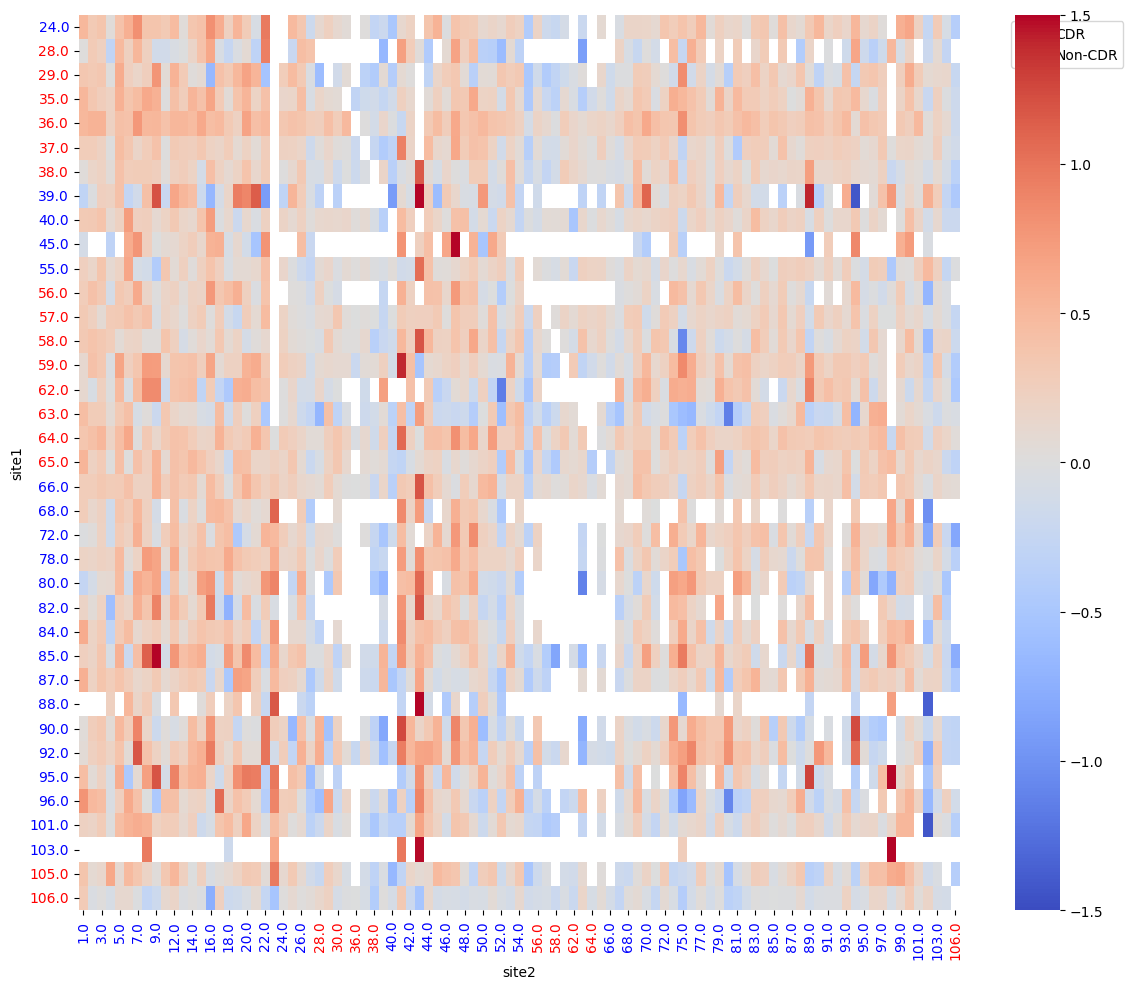

In [28]:
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df[(results_df.has_site1_mutation_branch_length > 50) & (results_df.total_mutations_acquired > 20)].pivot_table(index='site1', columns='site2', values='log_rate_ratio_mutcount'), vmin=-1.5, vmax=1.5, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

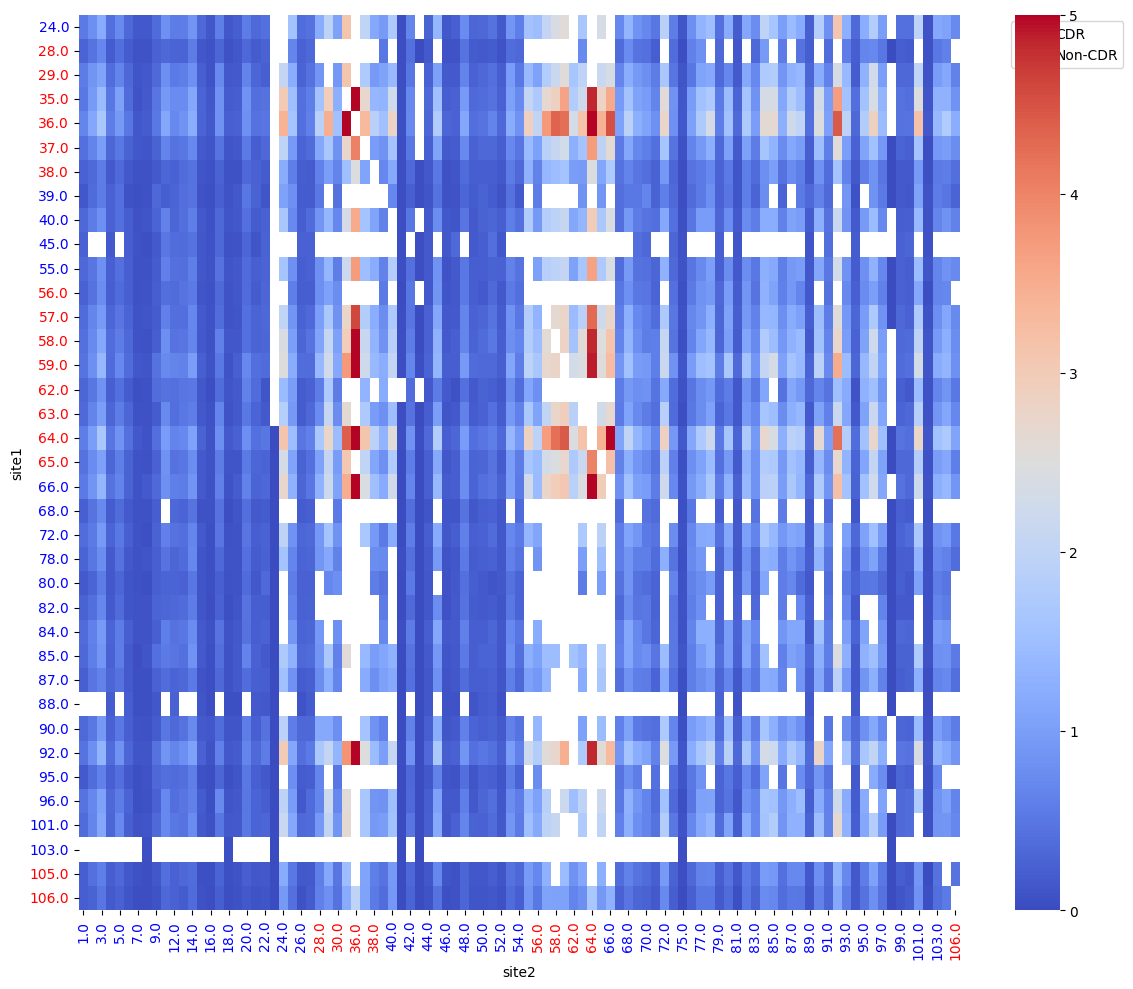

In [33]:
#percent_of_removed_unresolved_pcps


plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(results_df[(results_df.has_site1_mutation_branch_length > 50) & (results_df.total_mutations_acquired > 20)].pivot_table(index='site1', columns='site2', values='percent_of_removed_unresolved_pcps'), vmin=0, vmax=5, cmap="coolwarm", ax=ax)

# Get CDR information
cdr_info = site_sub_probs_df_germline[['site', 'is_cdr']].drop_duplicates().set_index('site')

# Color x-axis labels (site2)
for i, label in enumerate(ax.get_xticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Color y-axis labels (site1)
for i, label in enumerate(ax.get_yticklabels()):
    site = float(label.get_text())
    if site in cdr_info.index:
        color = 'red' if cdr_info.loc[site, 'is_cdr'] else 'blue'
        label.set_color(color)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='red', label='CDR'),
    Patch(facecolor='blue', label='Non-CDR')
]
ax.legend(handles=legend_elements, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.show()

<Axes: >

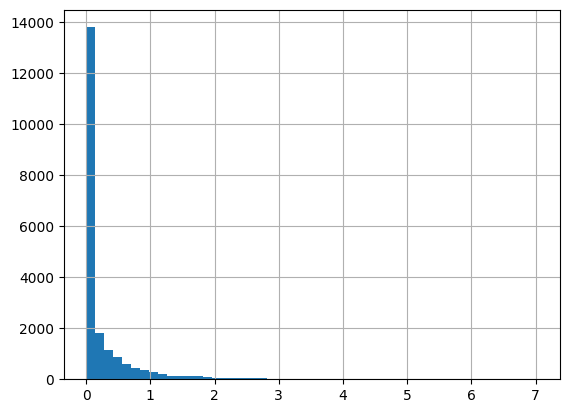

In [32]:
results_df.percent_of_removed_unresolved_pcps.hist(bins=50)

In [ ]:
# different v family backgrounds



def compare_mutation_rates_on_different_vfamilies(site_sub_probs_df_germline, site, vfamilies=['IGHV1', 'IGHV3', 'IGHV4']):
    '''
    Calculate mutation rates at a specific site across different V gene families.
    
    This function analyzes mutation rates at a given site across different V families,
    using branch length as a measure of evolutionary time.
    
    Parameters:
    -----------
    site_sub_probs_df_germline : pd.DataFrame
        DataFrame containing site substitution probabilities with columns:
        - 'site': site position
        - 'sample_id': sample identifier
        - 'family': family identifier
        - 'pcp_index': phylogenetic branch identifier
        - 'branch_length': evolutionary distance (substitutions per site)
        - 'germline_amino_acid': original amino acid at germline
        - 'is_germline_aa': boolean indicating if current AA matches germline
        - 'mutation': boolean indicating if site is mutated from germline
        - 'mutations_per_branch': total mutations accumulated on this branch
    
    vfamilies : list
        List of V gene families to compare (default: ['IGHV1', 'IGHV3', 'IGHV4'])
    site : int
        Site position to analyze
        
    Returns:
    --------
    list
        List of dictionaries containing mutation rate data for each V family:
        - 'vfamily': V gene family name
        - 'site': site position
        - 'branch_length': total branch length
        - 'mutations_per_branch': total mutations per branch
        - 'mutation_acquired': number of mutations acquired
        - 'rate': mutations per unit branch length
        - 'rate_mutcount': mutations per mutation count
        
    Notes:
    ------
    - Only analyzes branches where the site has germline amino acid identity
    - Handles cases with zero branch length or mutation count
    - Calculates both branch-length normalized and mutation-count normalized rates
    '''

    # filter only rows with the two relevant sites
    cur_df = site_sub_probs_df_germline[(site_sub_probs_df_germline['site'] == site) & (site_sub_probs_df_germline.v_family.isin(vfamilies))].copy()
    
    # filter only rows where germline identity is known
    cur_df = cur_df[(cur_df['germline_amino_acid'].notna())]

    vfamily_results = []
    vfamily_results_per_aa = []
    for vfamily in vfamilies:
        # filter for the current V family and only branches that have the germline amino acid at site
        vfamily_df = cur_df[(cur_df['v_family'] == vfamily) & (cur_df.is_germline_aa == True)].copy()
        if vfamily_df.empty:
            print(f"No data for V family {vfamily} at site {site}")
            continue
        # Calculate mutation rates for the current V family
        length = vfamily_df['branch_length'].sum()
        mutation_acquired = len(vfamily_df[(vfamily_df['mutation'] == True)])

        if length == 0:
            print(f"Zero branch length or mutation count for V family {vfamily} at site {site}")
            continue
        # Calculate mutation rates
        rate = mutation_acquired / length
        vfamily_results.append({
            'vfamily': vfamily,
            'site': site,
            'branch_length': length,
            'mutation_acquired': mutation_acquired,
            'rate': rate,
        })


        # calculate aa specific rates
        for amino_acid in vfamily_df['germline_amino_acid'].unique():
            aa_df = vfamily_df[vfamily_df['parent_aa'] == amino_acid]
            aa_length = aa_df['branch_length'].sum()
            if aa_df.empty:
                continue

            for target_amino_acid in AA_STR_SORTED:
                if amino_acid != target_amino_acid:
                    aa_mutation_acquired = len(aa_df[(aa_df['mutation'] == True) & (aa_df['child_aa'] == target_amino_acid)])
                    
                    # Calculate mutation rates for the specific amino acid
                    rate_aa = aa_mutation_acquired / aa_length
                    
                    vfamily_results_per_aa.append({
                        'vfamily': f"{vfamily}_{amino_acid}",
                        'site': site,
                        'parent_aa': amino_acid,
                        'child_aa': target_amino_acid,
                        'branch_length': aa_length,
                        'mutation_acquired': aa_mutation_acquired,
                        'rate': rate_aa,
                    })

    # Calculate totals from actual data
    total_counts = len(cur_df[['family', 'sample_id', 'pcp_index']].drop_duplicates())
    total_branch_length = cur_df['branch_length'].sum()
    total_mutations_acquired = len(cur_df[(cur_df['mutation'] == True)])
    
    
    return vfamily_results, vfamily_results_per_aa




In [67]:
vfamily_results, vfamily_results_per_aa = compare_mutation_rates_on_different_vfamilies(site_sub_probs_df_germline, 51, vfamilies=['IGHV1', 'IGHV3', 'IGHV4'])
vfamily_results

[{'vfamily': 'IGHV1',
  'site': 51,
  'branch_length': np.float64(143.98566531209997),
  'mutation_acquired': 64,
  'rate': np.float64(0.44448869171299166)},
 {'vfamily': 'IGHV3',
  'site': 51,
  'branch_length': np.float64(323.1927074767),
  'mutation_acquired': 269,
  'rate': np.float64(0.8323207602677517)},
 {'vfamily': 'IGHV4',
  'site': 51,
  'branch_length': np.float64(169.4913669968),
  'mutation_acquired': 79,
  'rate': np.float64(0.46610043567287723)}]

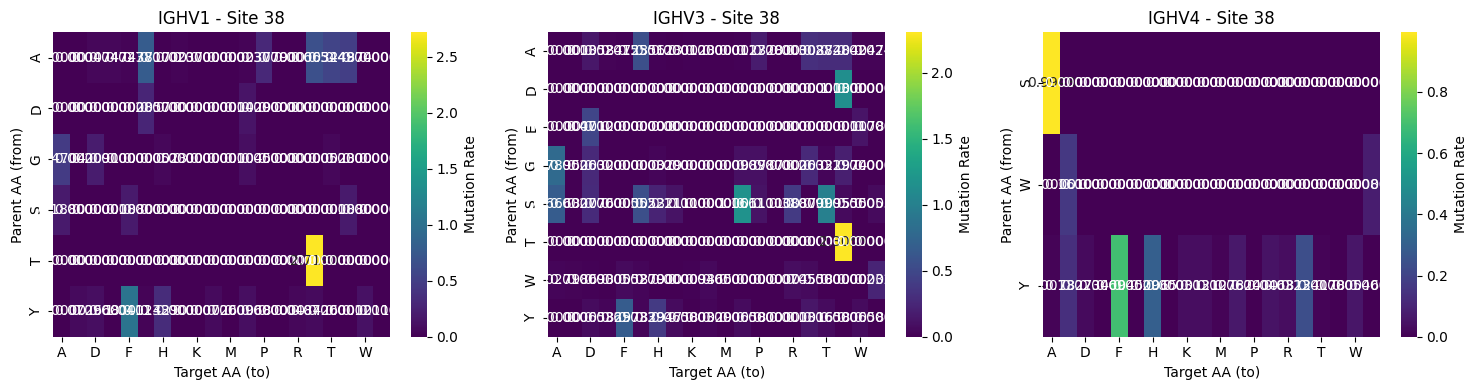


Mutation Rate Summary for Site 38:

IGHV1:
  Total mutation rate: 9.546389
  Highest single rate: 2.719034
  Most frequent mutation: T → S (2.719034)

IGHV3:
  Total mutation rate: 14.443999
  Highest single rate: 2.305453
  Most frequent mutation: T → V (2.305453)

IGHV4:
  Total mutation rate: 2.898506
  Highest single rate: 0.994758
  Most frequent mutation: S → A (0.994758)


{'IGHV1': child_aa          A         C         D         E         F         G  \
 parent_aa                                                               
 A          0.000000  0.000000  0.047374  0.047374  0.023687  0.781677   
 D          0.000000  0.000000  0.000000  0.000000  0.000000  0.285706   
 G          0.470365  0.000000  0.209051  0.000000  0.000000  0.000000   
 S          0.188026  0.000000  0.000000  0.000000  0.188026  0.000000   
 T          0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
 Y          0.000000  0.072635  0.096847  0.000000  1.041100  0.024212   
 
 child_aa          H         I    K         L    M         N         P    Q  \
 parent_aa                                                                    
 A          0.000000  0.023687  0.0  0.000000  0.0  0.023687  0.307933  0.0   
 D          0.000000  0.000000  0.0  0.000000  0.0  0.142853  0.000000  0.0   
 G          0.052263  0.000000  0.0  0.000000  0.0  0.104526  0.000000  0.0   
 S

In [58]:
import pandas as pd

def create_mutation_rate_pivot(vfamily_results_per_aa, site, vfamilies=['IGHV1', 'IGHV3', 'IGHV4']):
    """
    Create pivot tables showing mutation rates between amino acids for each V family.
    
    Parameters:
    -----------
    vfamily_results_per_aa : list
        List of dictionaries from compare_mutation_rates_on_different_vfamilies
        containing amino acid specific mutation rates
    site : int
        Site position being analyzed
    vfamilies : list
        List of V families to include in analysis
        
    Returns:
    --------
    dict
        Dictionary with V family names as keys and pivot tables as values.
        Each pivot table has:
        - Rows: parent amino acids (from)
        - Columns: target amino acids (to) 
        - Values: mutation rates
    """
    
    # Convert to DataFrame
    df = pd.DataFrame(vfamily_results_per_aa)
    
    if df.empty:
        print(f"No amino acid specific data found for site {site}")
        return {}
    
    # Extract V family name from the combined vfamily_aa column
    df['vfamily_clean'] = df['vfamily'].str.split('_').str[0]
    
    # Filter for the specified V families
    df = df[df['vfamily_clean'].isin(vfamilies)]
    
    pivot_tables = {}
    
    for vfamily in vfamilies:
        vfamily_data = df[df['vfamily_clean'] == vfamily]
        
        if vfamily_data.empty:
            print(f"No data for V family {vfamily} at site {site}")
            pivot_tables[vfamily] = pd.DataFrame()
            continue
            
        # Create pivot table with parent_aa as rows, child_aa as columns, rate as values
        pivot = vfamily_data.pivot_table(
            index='parent_aa',
            columns='child_aa', 
            values='rate',
            fill_value=0,
            aggfunc='sum'  # In case there are duplicates
        )
        
        pivot_tables[vfamily] = pivot
    
    return pivot_tables

def display_mutation_rate_pivots(vfamily_results_per_aa, site, vfamilies=['IGHV1', 'IGHV3', 'IGHV4'], 
                                show_heatmap=True, figsize=(15, 4)):
    """
    Create and display mutation rate pivot tables, optionally with heatmaps.
    
    Parameters:
    -----------
    vfamily_results_per_aa : list
        Results from compare_mutation_rates_on_different_vfamilies
    site : int
        Site position
    vfamilies : list
        V families to analyze
    show_heatmap : bool
        Whether to display heatmaps (default: True)
    figsize : tuple
        Figure size for heatmaps (default: (15, 4))
    """
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    pivot_tables = create_mutation_rate_pivot(vfamily_results_per_aa, site, vfamilies)
    
    if show_heatmap and pivot_tables:
        n_families = len([v for v in vfamilies if not pivot_tables[v].empty])
        
        if n_families > 0:
            fig, axes = plt.subplots(1, n_families, figsize=figsize, squeeze=False)
            axes = axes.flatten()
            
            plot_idx = 0
            for vfamily in vfamilies:
                if vfamily in pivot_tables and not pivot_tables[vfamily].empty:
                    # Create heatmap
                    sns.heatmap(pivot_tables[vfamily], 
                               annot=True, 
                               fmt='.4f', 
                               cmap='viridis',
                               ax=axes[plot_idx],
                               cbar_kws={'label': 'Mutation Rate'})
                    
                    axes[plot_idx].set_title(f'{vfamily} - Site {site}')
                    axes[plot_idx].set_xlabel('Target AA (to)')
                    axes[plot_idx].set_ylabel('Parent AA (from)')
                    plot_idx += 1
            
            # Hide unused subplots
            for idx in range(plot_idx, len(axes)):
                axes[idx].set_visible(False)
                
            plt.tight_layout()
            plt.show()
    
    # Print summary statistics
    print(f"\nMutation Rate Summary for Site {site}:")
    print("=" * 50)
    
    for vfamily in vfamilies:
        if vfamily in pivot_tables and not pivot_tables[vfamily].empty:
            pivot = pivot_tables[vfamily]
            total_rate = pivot.values.sum()
            max_rate = pivot.values.max()
            most_common = pivot.stack().idxmax()
            
            print(f"\n{vfamily}:")
            print(f"  Total mutation rate: {total_rate:.6f}")
            print(f"  Highest single rate: {max_rate:.6f}")
            print(f"  Most frequent mutation: {most_common[0]} → {most_common[1]} ({pivot.loc[most_common]:.6f})")
    
    return pivot_tables

# Usage example:
vfamily_results, vfamily_results_per_aa = compare_mutation_rates_on_different_vfamilies(
    site_sub_probs_df_germline, site=38, vfamilies=['IGHV1', 'IGHV3', 'IGHV4']
)

# Create pivot tables
pivots = create_mutation_rate_pivot(vfamily_results_per_aa, site=38)

# Display with heatmaps
display_mutation_rate_pivots(vfamily_results_per_aa, site=38, show_heatmap=True)

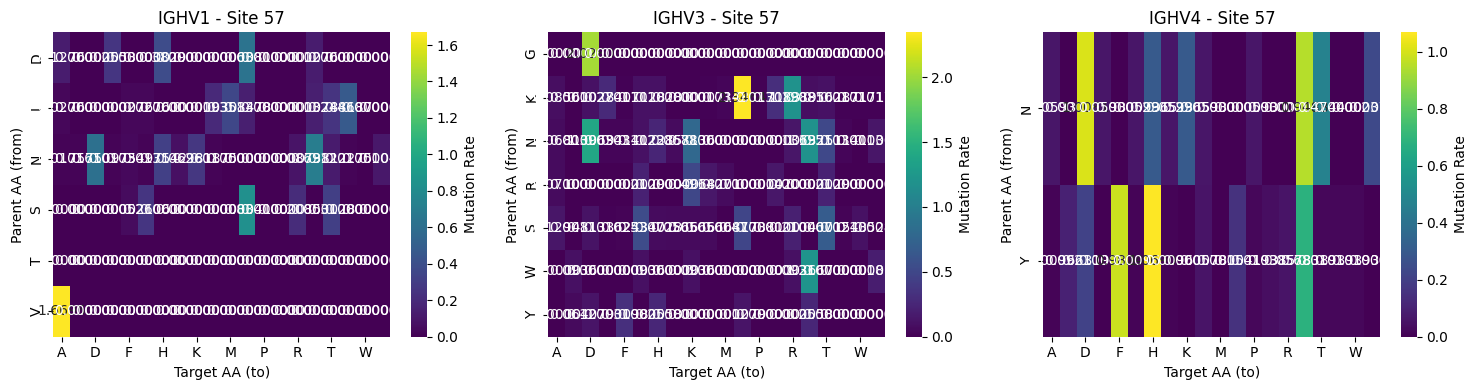


Mutation Rate Summary for Site 57:

IGHV1:
  Total mutation rate: 8.904265
  Highest single rate: 1.669489
  Most frequent mutation: V → A (1.669489)

IGHV3:
  Total mutation rate: 18.469582
  Highest single rate: 2.346364
  Most frequent mutation: K → N (2.346364)

IGHV4:
  Total mutation rate: 7.074691
  Highest single rate: 1.069033
  Most frequent mutation: Y → H (1.069033)


{'IGHV1': child_aa          A         C         D         E         F         G  \
 parent_aa                                                               
 D          0.127628  0.000000  0.000000  0.255256  0.000000  0.000000   
 I          0.027569  0.000000  0.000000  0.000000  0.027569  0.027569   
 N          0.017453  0.017453  0.610865  0.017453  0.034907  0.017453   
 S          0.000000  0.000000  0.000000  0.000000  0.052129  0.260646   
 T          0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
 V          1.669489  0.000000  0.000000  0.000000  0.000000  0.000000   
 
 child_aa          H         I         K         L         M         N    P  \
 parent_aa                                                                    
 D          0.382883  0.000000  0.000000  0.000000  0.000000  0.638139  0.0   
 I          0.000000  0.000000  0.000000  0.192981  0.358393  0.137844  0.0   
 N          0.314159  0.069813  0.261799  0.017453  0.000000  0.000000  0.0   
 S

In [62]:
site = 57
# Usage example:
vfamily_results, vfamily_results_per_aa = compare_mutation_rates_on_different_vfamilies(
    site_sub_probs_df_germline, site=site, vfamilies=['IGHV1', 'IGHV3', 'IGHV4']
)

# Create pivot tables
pivots = create_mutation_rate_pivot(vfamily_results_per_aa, site=site)

# Display with heatmaps
display_mutation_rate_pivots(vfamily_results_per_aa, site=site, show_heatmap=True)

In [126]:
df = pd.read_csv('/home/nharel/data/epistasis/mutation_rates_on_different_backgrounds/mutation_rates_on_different_vfamilies_v1tang_20250727_192056_overall_mutation_rates.csv')
df_aa = pd.read_csv('/home/nharel/data/epistasis/mutation_rates_on_different_backgrounds/mutation_rates_on_different_vfamilies_v1tang_20250727_192056_per_aa_mutation_rates.csv')

In [173]:
df = pd.read_csv('/home/nharel/data/epistasis/mutation_rates_on_different_backgrounds/mutation_rates_on_different_vfamilies_v1tang_20250727_203456_no_leaves_overall_mutation_rates.csv')
df_aa = pd.read_csv('/home/nharel/data/epistasis/mutation_rates_on_different_backgrounds/mutation_rates_on_different_vfamilies_v1tang_20250727_203456_no_leaves_per_aa_mutation_rates.csv')

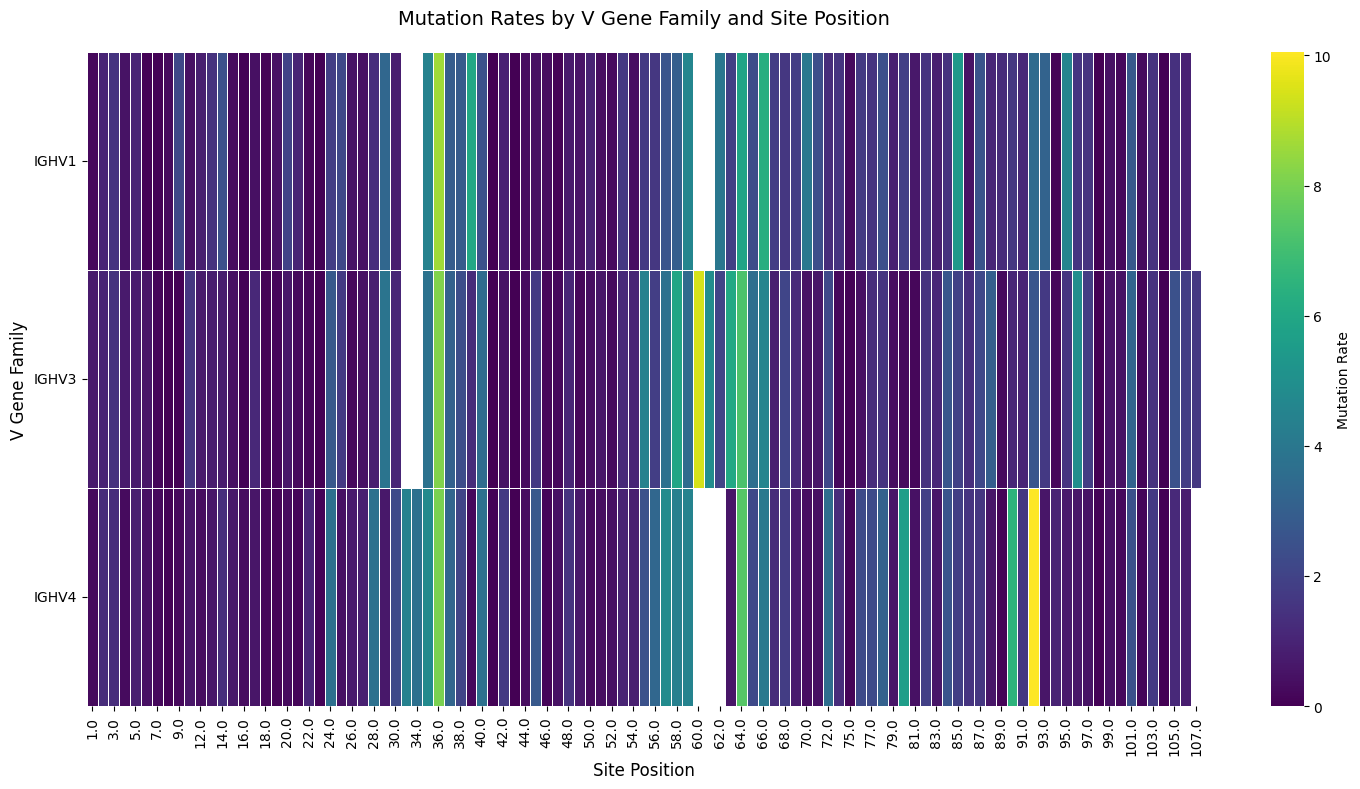

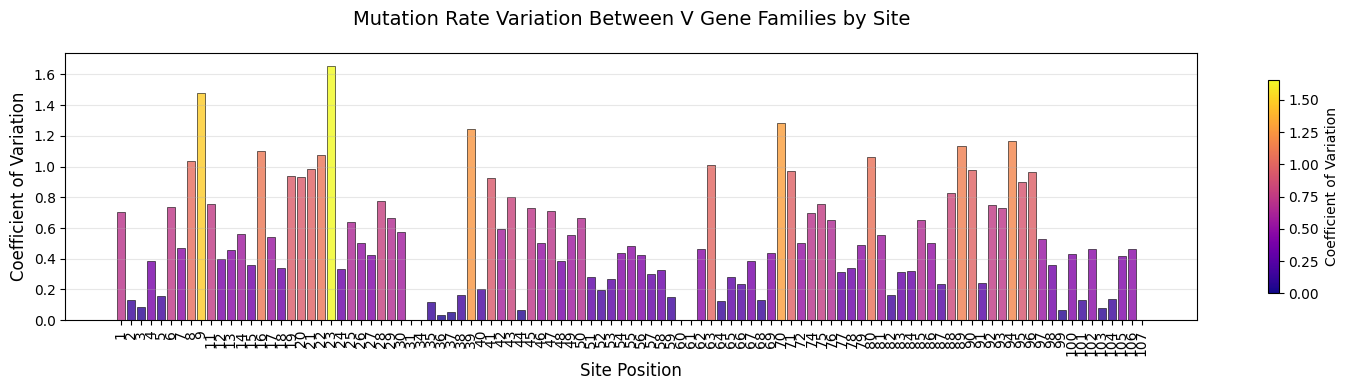


Summary Statistics:
Sites analyzed: 103
V families: 3
Overall rate range: nan - nan
Highest rate: 10.0552 (IGHV4 at site 92.0)
Lowest rate: 0.0000 (IGHV1 at site 23.0)

Average rates by V family:
  IGHV4: 1.6219
  IGHV1: 1.6087
  IGHV3: 1.5984

Variation between V families per site:
Top 10 sites with highest coefficient of variation:
  Site 23.0: CV=1.657, Max diff=0.0439 (IGHV1 vs IGHV4)
  Site 9.0: CV=1.480, Max diff=2.1226 (IGHV1 vs IGHV3)
  Site 70.0: CV=1.283, Max diff=3.6627 (IGHV1 vs IGHV4)
  Site 39.0: CV=1.246, Max diff=5.8055 (IGHV1 vs IGHV4)
  Site 94.0: CV=1.165, Max diff=0.8550 (IGHV1 vs IGHV4)
  Site 89.0: CV=1.132, Max diff=1.1342 (IGHV1 vs IGHV4)
  Site 16.0: CV=1.098, Max diff=0.2773 (IGHV3 vs IGHV4)
  Site 22.0: CV=1.076, Max diff=0.9203 (IGHV1 vs IGHV4)
  Site 80.0: CV=1.063, Max diff=5.3544 (IGHV3 vs IGHV4)
  Site 8.0: CV=1.037, Max diff=0.2332 (IGHV1 vs IGHV3)

Top 10 sites with highest fold change:
  Site 23.0: Fold change=inf, Max diff=0.0439 (IGHV1 vs IGHV4)
  

NameError: name 'ax2' is not defined

In [167]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def create_vfamily_site_heatmap(df, figsize=(15, 8), save_path=None):
    """
    Create a heatmap showing mutation rates per V family across sites.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: vfamily, site, rate (and optionally branch_length, mutation_acquired)
    figsize : tuple
        Figure size (width, height)
    save_path : str, optional
        Path to save the figure
        
    Returns:
    --------
    fig, ax : matplotlib figure and axes objects
    """
    
    # Create pivot table with vfamily as rows and site as columns, rate as values
    pivot_table = df.pivot_table(
        index='vfamily', 
        columns='site', 
        values='rate', 
        aggfunc='mean'  # In case there are duplicates
    )
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=figsize)
    
    # Create heatmap without annotations
    sns.heatmap(pivot_table, 
                cmap='viridis',
                cbar_kws={'label': 'Mutation Rate'},
                linewidths=0.5,
                linecolor='white',
                ax=ax)
    
    # Customize the plot
    ax.set_title('Mutation Rates by V Gene Family and Site Position', fontsize=14, pad=20)
    ax.set_xlabel('Site Position', fontsize=12)
    ax.set_ylabel('V Gene Family', fontsize=12)
    
    # Rotate x-axis labels for better readability
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90,)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap saved to {save_path}")
    
    plt.show()
    
    return fig, ax, pivot_table

def create_vfamily_variation_plot(df, figsize=(15, 4), save_path=None):
    """
    Create a separate bar plot showing variation in mutation rates between V families per site.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with columns: vfamily, site, rate
    figsize : tuple
        Figure size (width, height)
    save_path : str, optional
        Path to save the figure
        
    Returns:
    --------
    fig, ax, variation_df : matplotlib figure, axes, and variation statistics DataFrame
    """
    
    # Create pivot table
    pivot_table = df.pivot_table(
        index='vfamily', 
        columns='site', 
        values='rate', 
        aggfunc='mean'
    )
    
    # Calculate coefficient of variation for each site
    site_variation_stats = []
    site_cv = []
    
    for site in pivot_table.columns:
        site_rates = pivot_table[site].dropna()
        
        if len(site_rates) > 1:  # Need at least 2 V families for comparison
            # Calculate various measures of variation
            site_std = site_rates.std()
            site_cv_val = site_std / site_rates.mean() if site_rates.mean() > 0 else 0
            site_range = site_rates.max() - site_rates.min()
            site_fold_change = site_rates.max() / site_rates.min() if site_rates.min() > 0 else np.inf
            
            # Calculate pairwise differences
            rate_diffs = []
            vfamily_pairs = []
            for i, vfam1 in enumerate(site_rates.index):
                for j, vfam2 in enumerate(site_rates.index):
                    if i < j:  # Avoid duplicates
                        diff = abs(site_rates[vfam1] - site_rates[vfam2])
                        rate_diffs.append(diff)
                        vfamily_pairs.append((vfam1, vfam2))
            
            max_diff = max(rate_diffs) if rate_diffs else 0
            max_diff_pair = vfamily_pairs[rate_diffs.index(max_diff)] if rate_diffs else ('', '')
            
            site_variation_stats.append({
                'site': site,
                'n_families': len(site_rates),
                'mean_rate': site_rates.mean(),
                'std_dev': site_std,
                'coeff_variation': site_cv_val,
                'rate_range': site_range,
                'fold_change': site_fold_change,
                'max_pairwise_diff': max_diff,
                'max_diff_pair': f"{max_diff_pair[0]} vs {max_diff_pair[1]}"
            })
            site_cv.append(site_cv_val)
        else:
            site_cv.append(0)
    
    # Create variation bar plot
    fig, ax = plt.subplots(figsize=figsize)
    
    sites = list(pivot_table.columns)
    colors = plt.cm.plasma(np.array(site_cv) / max(site_cv) if max(site_cv) > 0 else np.zeros_like(site_cv))
    
    bars = ax.bar(range(len(sites)), site_cv, color=colors, 
                  edgecolor='black', linewidth=0.5, alpha=0.8)
    
    # Customize variation plot
    ax.set_title('Mutation Rate Variation Between V Gene Families by Site', fontsize=14, pad=20)
    ax.set_ylabel('Coefficient of Variation', fontsize=12)
    ax.set_xlabel('Site Position', fontsize=12)
    ax.set_xticks(range(len(sites)))
    ax.set_xticklabels([str(int(site)) for site in sites], rotation=90)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Add colorbar for variation
    sm = plt.cm.ScalarMappable(cmap='plasma', norm=plt.Normalize(vmin=0, vmax=max(site_cv) if site_cv else 1))
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, shrink=0.8)
    cbar.set_label('Coefficient of Variation', fontsize=10)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Variation plot saved to {save_path}")
    
    plt.show()
    
    # Convert to DataFrame for easier handling
    variation_df = pd.DataFrame(site_variation_stats)
    
    # Print summary statistics
    print("\nSummary Statistics:")
    print("=" * 50)
    print(f"Sites analyzed: {len(pivot_table.columns)}")
    print(f"V families: {len(pivot_table.index)}")
    print(f"Overall rate range: {pivot_table.values.min():.4f} - {pivot_table.values.max():.4f}")
    
    # Find highest and lowest rates
    max_rate_pos = np.unravel_index(np.nanargmax(pivot_table.values), pivot_table.shape)
    min_rate_pos = np.unravel_index(np.nanargmin(pivot_table.values), pivot_table.shape)
    
    max_vfamily = pivot_table.index[max_rate_pos[0]]
    max_site = pivot_table.columns[max_rate_pos[1]]
    max_rate = pivot_table.iloc[max_rate_pos]
    
    min_vfamily = pivot_table.index[min_rate_pos[0]]
    min_site = pivot_table.columns[min_rate_pos[1]]
    min_rate = pivot_table.iloc[min_rate_pos]
    
    print(f"Highest rate: {max_rate:.4f} ({max_vfamily} at site {max_site})")
    print(f"Lowest rate: {min_rate:.4f} ({min_vfamily} at site {min_site})")
    
    # Show rates by V family (average across sites)
    print("\nAverage rates by V family:")
    vfamily_means = pivot_table.mean(axis=1).sort_values(ascending=False)
    for vfamily, rate in vfamily_means.items():
        print(f"  {vfamily}: {rate:.4f}")
    
    # Calculate measures of variation between V families per site
    print("\nVariation between V families per site:")
    print("=" * 50)
    
    site_variation_stats = []
    for site in pivot_table.columns:
        site_rates = pivot_table[site].dropna()  # Remove NaN values
        
        if len(site_rates) > 1:  # Need at least 2 V families for comparison
            # Calculate various measures of variation
            site_std = site_rates.std()
            site_cv = site_std / site_rates.mean() if site_rates.mean() > 0 else np.nan  # Coefficient of variation
            site_range = site_rates.max() - site_rates.min()
            site_fold_change = site_rates.max() / site_rates.min() if site_rates.min() > 0 else np.inf
            
            # Calculate pairwise differences
            rate_diffs = []
            vfamily_pairs = []
            for i, vfam1 in enumerate(site_rates.index):
                for j, vfam2 in enumerate(site_rates.index):
                    if i < j:  # Avoid duplicates
                        diff = abs(site_rates[vfam1] - site_rates[vfam2])
                        rate_diffs.append(diff)
                        vfamily_pairs.append((vfam1, vfam2))
            
            max_diff = max(rate_diffs) if rate_diffs else 0
            max_diff_pair = vfamily_pairs[rate_diffs.index(max_diff)] if rate_diffs else ('', '')
            
            site_variation_stats.append({
                'site': site,
                'n_families': len(site_rates),
                'mean_rate': site_rates.mean(),
                'std_dev': site_std,
                'coeff_variation': site_cv,
                'rate_range': site_range,
                'fold_change': site_fold_change,
                'max_pairwise_diff': max_diff,
                'max_diff_pair': f"{max_diff_pair[0]} vs {max_diff_pair[1]}"
            })
    
    # Convert to DataFrame for easier handling
    variation_df = pd.DataFrame(site_variation_stats)
    
    # Show top sites with highest variation
    print("Top 10 sites with highest coefficient of variation:")
    top_cv_sites = variation_df.nlargest(10, 'coeff_variation')[['site', 'coeff_variation', 'max_pairwise_diff', 'max_diff_pair']]
    for _, row in top_cv_sites.iterrows():
        print(f"  Site {row['site']}: CV={row['coeff_variation']:.3f}, Max diff={row['max_pairwise_diff']:.4f} ({row['max_diff_pair']})")
    
    print("\nTop 10 sites with highest fold change:")
    top_fold_sites = variation_df.nlargest(10, 'fold_change')[['site', 'fold_change', 'max_pairwise_diff', 'max_diff_pair']]
    for _, row in top_fold_sites.iterrows():
        fold_str = f"{row['fold_change']:.2f}" if np.isfinite(row['fold_change']) else "inf"
        print(f"  Site {row['site']}: Fold change={fold_str}, Max diff={row['max_pairwise_diff']:.4f} ({row['max_diff_pair']})")
    
    return fig, (ax1, ax2), pivot_table, variation_df

def create_vfamily_site_heatmap_with_counts(df, figsize=(15, 8), save_path=None):
    """
    Create a heatmap with mutation rates, annotated with mutation counts.
    
    Parameters are the same as create_vfamily_site_heatmap.
    """
    
    # Create pivot tables for both rate and mutation counts
    rate_pivot = df.pivot_table(index='vfamily', columns='site', values='rate', aggfunc='mean')
    count_pivot = df.pivot_table(index='vfamily', columns='site', values='mutation_acquired', aggfunc='sum')
    
    # Create custom annotations combining rate and count
    annotations = rate_pivot.copy().astype(str)
    for i in range(len(rate_pivot.index)):
        for j in range(len(rate_pivot.columns)):
            if not pd.isna(rate_pivot.iloc[i, j]):
                rate_val = rate_pivot.iloc[i, j]
                count_val = int(count_pivot.iloc[i, j]) if not pd.isna(count_pivot.iloc[i, j]) else 0
                annotations.iloc[i, j] = f"{rate_val:.3f}\n(n={count_val})"
            else:
                annotations.iloc[i, j] = ""
    
    # Create the heatmap
    fig, ax = plt.subplots(figsize=figsize)
    
    sns.heatmap(rate_pivot, 
                annot=annotations, 
                fmt='',  # String format since we're using custom annotations
                cmap='viridis',
                cbar_kws={'label': 'Mutation Rate'},
                linewidths=0.5,
                linecolor='white',
                ax=ax)
    
    ax.set_title('Mutation Rates by V Gene Family and Site Position\n(with mutation counts)', fontsize=14, pad=20)
    ax.set_xlabel('Site Position', fontsize=12)
    ax.set_ylabel('V Gene Family', fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Heatmap with counts saved to {save_path}")
    
    plt.show()
    
    return fig, ax, rate_pivot
# Create clean heatmap
fig1, ax1, pivot_table = create_vfamily_site_heatmap(df)

# Create separate variation plot  
fig2, ax2, variation_df = create_vfamily_variation_plot(df)

# Analyze high-variation sites
top_variable_sites = variation_df.nlargest(5, 'coeff_variation')
print(top_variable_sites[['site', 'coeff_variation', 'max_diff_pair']])



In [129]:
df_aa

,vfamily,site,parent_aa,child_aa,branch_length,mutation_acquired,rate
0,IGHV1,1.0,Q,A,1477.738724,0,0.000000
1,IGHV1,1.0,Q,C,1477.738724,0,0.000000
2,IGHV1,1.0,Q,D,1477.738724,1,0.000677
3,IGHV1,1.0,Q,E,1477.738724,162,0.109627
4,IGHV1,1.0,Q,F,1477.738724,0,0.000000
...,...,...,...,...,...,...,...
10198,IGHV3,107.0,D,S,149.402124,5,0.033467
10199,IGHV3,107.0,D,T,149.402124,1,0.006693
10200,IGHV3,107.0,D,V,149.402124,16,0.107094
10201,IGHV3,107.0,D,W,149.402124,0,0.000000


IGHV1
IGHV3
IGHV4


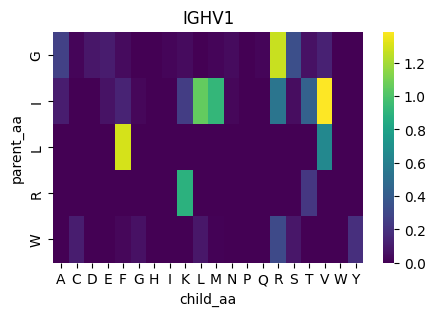

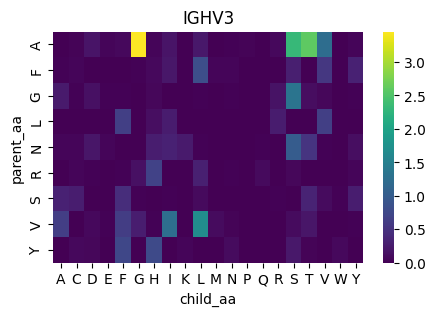

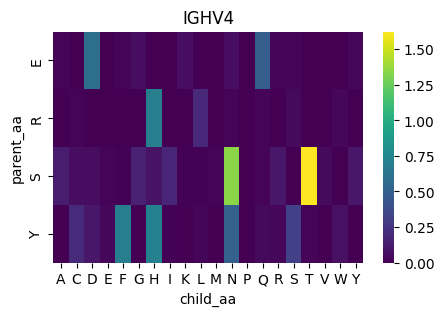

In [184]:
cur_df = df_aa[df_aa.site == 55]
for v_family in cur_df.vfamily.unique():
    print(v_family)
    plot_df = cur_df[cur_df.vfamily == v_family].pivot_table(index='parent_aa', columns='child_aa', values='rate', fill_value=0, )
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.heatmap(plot_df, cmap='viridis', xticklabels=True, yticklabels=True)
    ax.set_title(v_family)



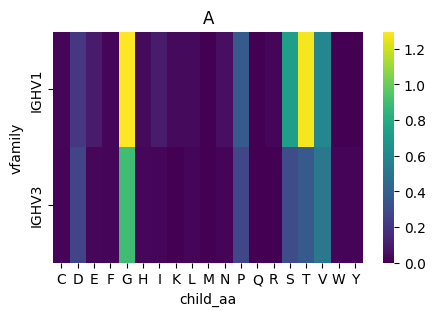

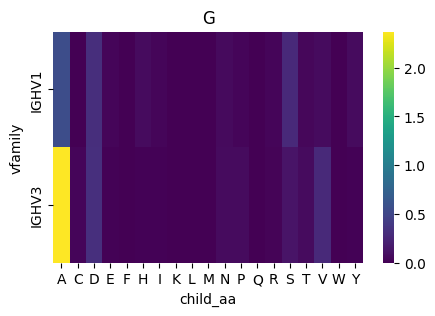

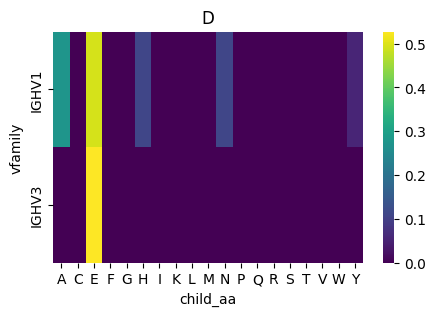

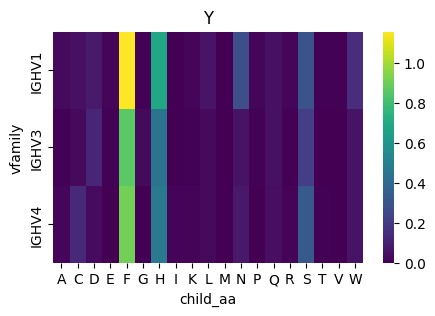

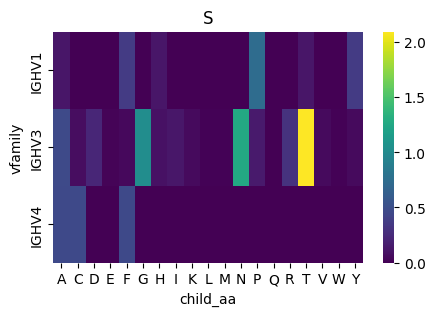

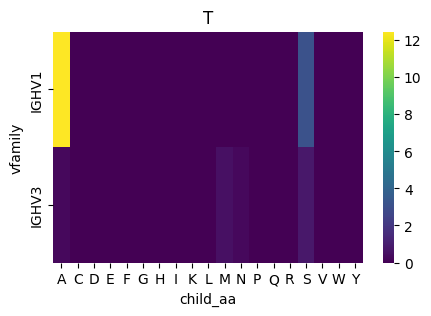

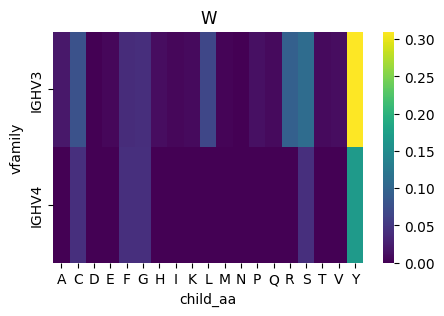

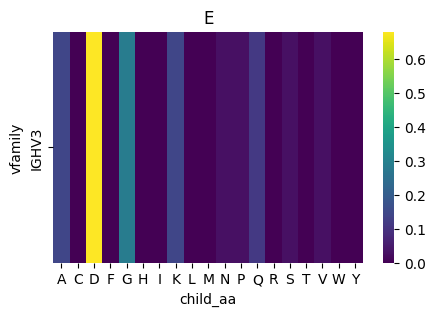

In [174]:
cur_df = df_aa[df_aa.site 
== 38]
for parent_aa in cur_df.parent_aa.unique():
    plot_df = cur_df[cur_df.parent_aa == parent_aa].pivot_table(index='vfamily', columns='child_aa', values='rate')
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.heatmap(plot_df, cmap='viridis', xticklabels=True, yticklabels=True, vmin=0)
    ax.set_title(parent_aa)



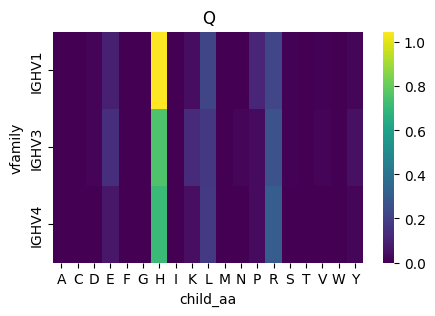

In [153]:
cur_df = df_aa[df_aa.site == 3]
for parent_aa in cur_df.parent_aa.unique():
    plot_df = cur_df[cur_df.parent_aa == parent_aa].pivot_table(index='vfamily', columns='child_aa', values='rate')
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.heatmap(plot_df, cmap='viridis', xticklabels=True, yticklabels=True, vmin=0)
    ax.set_title(parent_aa)



IGHV1
IGHV3
IGHV4


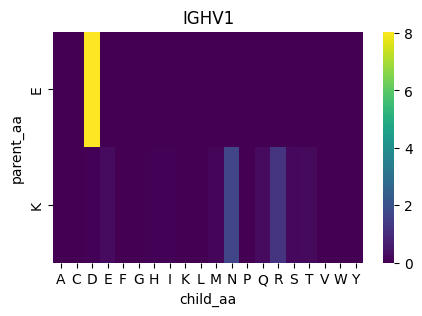

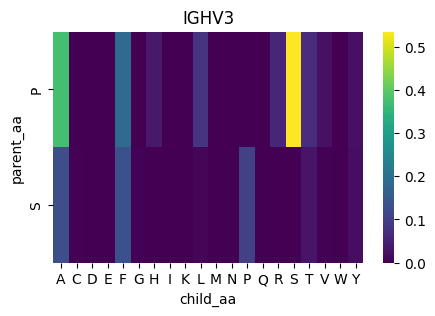

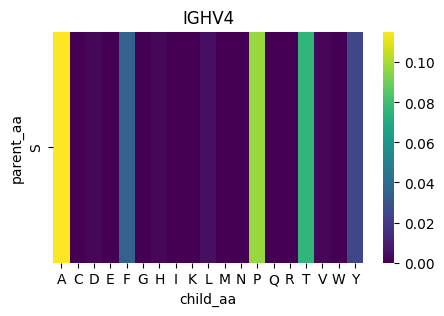

In [175]:
cur_df = df_aa[df_aa.site == 70]
for v_family in cur_df.vfamily.unique():
    print(v_family)
    plot_df = cur_df[cur_df.vfamily == v_family].pivot_table(index='parent_aa', columns='child_aa', values='rate', fill_value=0, )
    fig, ax = plt.subplots(figsize=(5, 3))
    sns.heatmap(plot_df, cmap='viridis', xticklabels=True, yticklabels=True)
    ax.set_title(v_family)

